In [20]:
import os
import yaml
import h5py
import glob
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import confusion_matrix


In [21]:
# =============================================================================
# CONFIGURATION — set these paths before running the notebook
# =============================================================================
PREDICTIONS_DIR = Path("./predictions")          # model prediction .h5 files
HM_DIR          = Path("./human_vs_machine")     # human-vs-machine data
SPLIT_FILE      = Path("./train_val_split.yaml") # train/validation split
LABEL_MAP_FILE  = Path("./Tumor_label_mapping.yaml")
LABEL_DIR       = Path("./labels")  

# Reproducibility
random.seed(42)
np.random.seed(42)


In [22]:
class Predictions:
    def __init__(
        self,
        pred_file_path: str,
        ID_mapping: bool = False,
        label_file_path: str = "./labels/UKHD_train_val.csv",  # default UKHD labels
        extra_info_path: str = "./hierarchy_color.xlsx",
        mapping_path: str = "./Tumor_label_mapping.yaml",
    ):
        if os.path.isdir(pred_file_path):
            pred_files = sorted(glob.glob(os.path.join(pred_file_path, "*.h5")))
            for idx, pred in enumerate(pred_files):
                with h5py.File(pred, "r") as f:
                    prob = f["probs"][:]
                    label = f["labels"][:]
                    slide_id = f["slide_id"][:].astype(str).tolist()
                    if idx == 0:
                        mean_prob = prob
                    else:
                        mean_prob += prob
            mean_prob /= len(pred_files)
        else:
            with h5py.File(pred_file_path, "r") as f:
                mean_prob = f["probs"][:]
                label = f["labels"][:]
                slide_id = f["slide_id"][:].astype(str).tolist()

        self.mean_prob = mean_prob[:, :108]  # 108-185 dims are redundant
        self.label = label
        self.slide_id = slide_id

        with open(mapping_path, "r") as fid:
            self.str2int_mapping = yaml.safe_load(fid)["mapping"]
        self.int2str_mapping = {v: k for k, v in self.str2int_mapping.items()}

        self.label_file = pd.read_csv(label_file_path)
        self.label_file["slide_ID"] = self.label_file["slide_ID"].astype(str)
        self.predictions = pd.DataFrame(
            {"slide_ID": self.slide_id}
        )  # default type str for slide_ID

        ### only for some special cases in external validation, convert the format of slide_ID
        if ID_mapping:
            self.label_file["slide_ID"] = self.label_file["slide_path"].apply(
                lambda x: os.path.basename(x).split(".")[0]
            )

        self.predictions = pd.merge(
            self.predictions,
            self.label_file[["slide_ID", "class", "MC_score"]].drop_duplicates(
                subset=["slide_ID"]
            ),
            how="left",
            on="slide_ID",
        )

        self.predictions["labels"] = self.predictions["class"].map(self.str2int_mapping)
        self.predictions["top1_conf"] = np.max(mean_prob, axis=1)
        self.predictions["top3_conf"] = np.sort(mean_prob, axis=1)[:, -3:].sum(
            axis=1
        )  # sum of top3 confidences
        self.predictions["pred1"] = np.argmax(mean_prob, axis=1)
        self.predictions["pred2"] = np.argsort(mean_prob, axis=1)[:, -2]
        self.predictions["pred3"] = np.argsort(mean_prob, axis=1)[:, -3]
        self.predictions["top3_match"] = self.predictions.apply(
            lambda x: x["labels"] in [x["pred1"], x["pred2"], x["pred3"]], axis=1
        )

        self.extra_info = pd.read_excel(
            extra_info_path
        )  # including hierarchy info and color code

    def filter_methy_preds_confidence(
        self, m_threshold: float = 0, p_threshold: float = 0
    ):
        filtered_predictions = self.predictions[
            (self.predictions["MC_score"] > m_threshold)
            & (self.predictions["top1_conf"] > p_threshold)
        ]
        return filtered_predictions

    def get_color_mapping(self):
        # {tumor_class_name: color_code}
        color_df = self.extra_info[["Class", "color_code_class"]].copy()
        color_df.dropna(subset=["color_code_class"], inplace=True)
        color_df["color_code_class"] = color_df["color_code_class"].apply(
            lambda x: x[:7]
        )
        color_mapping = color_df.set_index("Class")["color_code_class"].to_dict()
        return color_mapping

    def get_cls_wise_results(self, filtered_predictions: pd.DataFrame = None):
        if filtered_predictions is None:
            filtered_predictions = self.predictions
        filtered_predictions["match"] = (
            filtered_predictions["labels"] == filtered_predictions["pred1"]
        )
        cls_wise_df = (
            filtered_predictions.groupby("class")["match"]
            .mean()
            .reset_index(name="accuracy")
        )
        sample_count = (
            filtered_predictions.groupby("class")
            .size()
            .reset_index(name="sample_count")
        )
        merged_df = pd.merge(cls_wise_df, sample_count, on="class")
        return merged_df

    def plot_classification_report(
        self, filtered_predictions: pd.DataFrame = None, thresh: float = 0.5
    ):
        if filtered_predictions is None:
            filtered_predictions = self.predictions
        overall_acc = np.mean(
            filtered_predictions["labels"] == filtered_predictions["pred1"]
        )
        print("Accuracy of all predictions:", overall_acc * 100, "%")

        top3_acc = np.mean(filtered_predictions["top3_match"])
        print("Top3 accuracy:", top3_acc * 100, "%\n")

        high_conf_preds_ratio = np.mean(filtered_predictions["top1_conf"] > thresh)
        print(
            f"Ratio of high confidence (>{thresh}) predictions:",
            high_conf_preds_ratio * 100,
            "%",
        )

        high_conf_preds = filtered_predictions[
            filtered_predictions["top1_conf"] > thresh
        ]
        high_conf_acc = np.mean(high_conf_preds["labels"] == high_conf_preds["pred1"])
        high_conf_top3_acc = np.mean(high_conf_preds["top3_match"])
        print("Accuracy of high confidence predictions:", high_conf_acc * 100, "%")
        print(
            "Top3 accuracy of high confidence predictions:",
            high_conf_top3_acc * 100,
            "%",
        )

    def plot_confidence_distribution(self, filtered_predictions: pd.DataFrame = None):
        if filtered_predictions is None:
            filtered_predictions = self.predictions
        bins = [i / 10 for i in range(11)]
        labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]
        filtered_predictions["y_max_bin"] = pd.cut(
            filtered_predictions["top1_conf"],
            bins=bins,
            labels=labels,
            include_lowest=True,
        )
        tmp = filtered_predictions["y_max_bin"].value_counts().sort_index()
        print(filtered_predictions["y_max_bin"].value_counts().sort_index())

        plt.figure(figsize=(8, 6))
        plt.rcParams["font.family"] = "Arial"
        sns.histplot(
            filtered_predictions["y_max_bin"],
            discrete=True,
            alpha=0.7,
        )
        plt.xlabel("Predicted_confidence distribution", fontsize=13, labelpad=10)
        plt.ylabel("Count", fontsize=13, labelpad=10)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=12)
        plt.box(False)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()
        return tmp

    def filter_classes(self, classes: list, filtered_predictions: pd.DataFrame = None):
        if filtered_predictions is None:
            filtered_predictions = self.predictions
        filtered_predictions = filtered_predictions[
            filtered_predictions["labels"].isin(classes)
        ]
        return filtered_predictions

    def plot_acc_count_heatmap(
        self, filtered_predictions: pd.DataFrame = None, accumulation: bool = True
    ):
        if filtered_predictions is None:
            filtered_predictions = self.predictions
        acc_matrix = np.zeros((10, 10))
        count_matrix = np.zeros((10, 10), dtype=np.int64)
        filtered_predictions["is_correct"] = (
            filtered_predictions["labels"] == filtered_predictions["pred1"]
        )

        for class_num, class_conf in enumerate(np.linspace(0, 0.9, 10)):
            for model_num, model_conf in enumerate(np.linspace(0, 0.9, 10)):
                if accumulation:
                    df_subset = filtered_predictions[
                        (filtered_predictions["MC_score"] > class_conf)
                        & (filtered_predictions["top1_conf"] > model_conf)
                    ]["is_correct"]
                else:
                    df_subset = filtered_predictions[
                        (filtered_predictions["MC_score"] > class_conf)
                        & (filtered_predictions["top1_conf"] > model_conf)
                        & (filtered_predictions["MC_score"] <= class_conf + 0.1)
                        & (filtered_predictions["top1_conf"] <= model_conf + 0.1)
                    ]["is_correct"]
                acc_matrix[class_num, model_num] = df_subset.mean()
                count_matrix[class_num, model_num] = len(df_subset)

        fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
        axs = axs.flatten()
        sns.heatmap(
            acc_matrix,
            annot=True,
            xticklabels=np.linspace(0, 0.9, 10).astype(np.float32),
            yticklabels=np.linspace(0, 0.9, 10).astype(np.float32),
            ax=axs[0],
            annot_kws={"size": 9},
        )
        axs[0].set_xlabel("Model confidence threshold")
        axs[0].set_ylabel("Classifier confidence threshold")
        axs[0].invert_yaxis()
        axs[0].set_title("Accuracy")

        sns.heatmap(
            count_matrix,
            annot=True,
            xticklabels=np.linspace(0, 0.9, 10).astype(np.float32),
            yticklabels=np.linspace(0, 0.9, 10).astype(np.float32),
            ax=axs[1],
            fmt="d",
            annot_kws={"size": 9},
        )
        axs[1].set_xlabel("Model confidence threshold")
        axs[1].invert_yaxis()
        axs[1].set_title("Slides left")
        plt.show()

## Figure 2c: Accuracy vs. Prediction Confidence Scatter Plot


In [23]:
ukhd_preds_path = PREDICTIONS_DIR / "avg_ukhd_preds.h5"
ukhd_preds = Predictions(ukhd_preds_path)  # load UKHD predictions
ukhd_preds.plot_classification_report()  # print classification report

Accuracy of all predictions: 74.9546279491833 %
Top3 accuracy: 87.38656987295825 %

Ratio of high confidence (>0.5) predictions: 69.23774954627949 %
Accuracy of high confidence predictions: 87.81127129750983 %
Top3 accuracy of high confidence predictions: 94.4954128440367 %


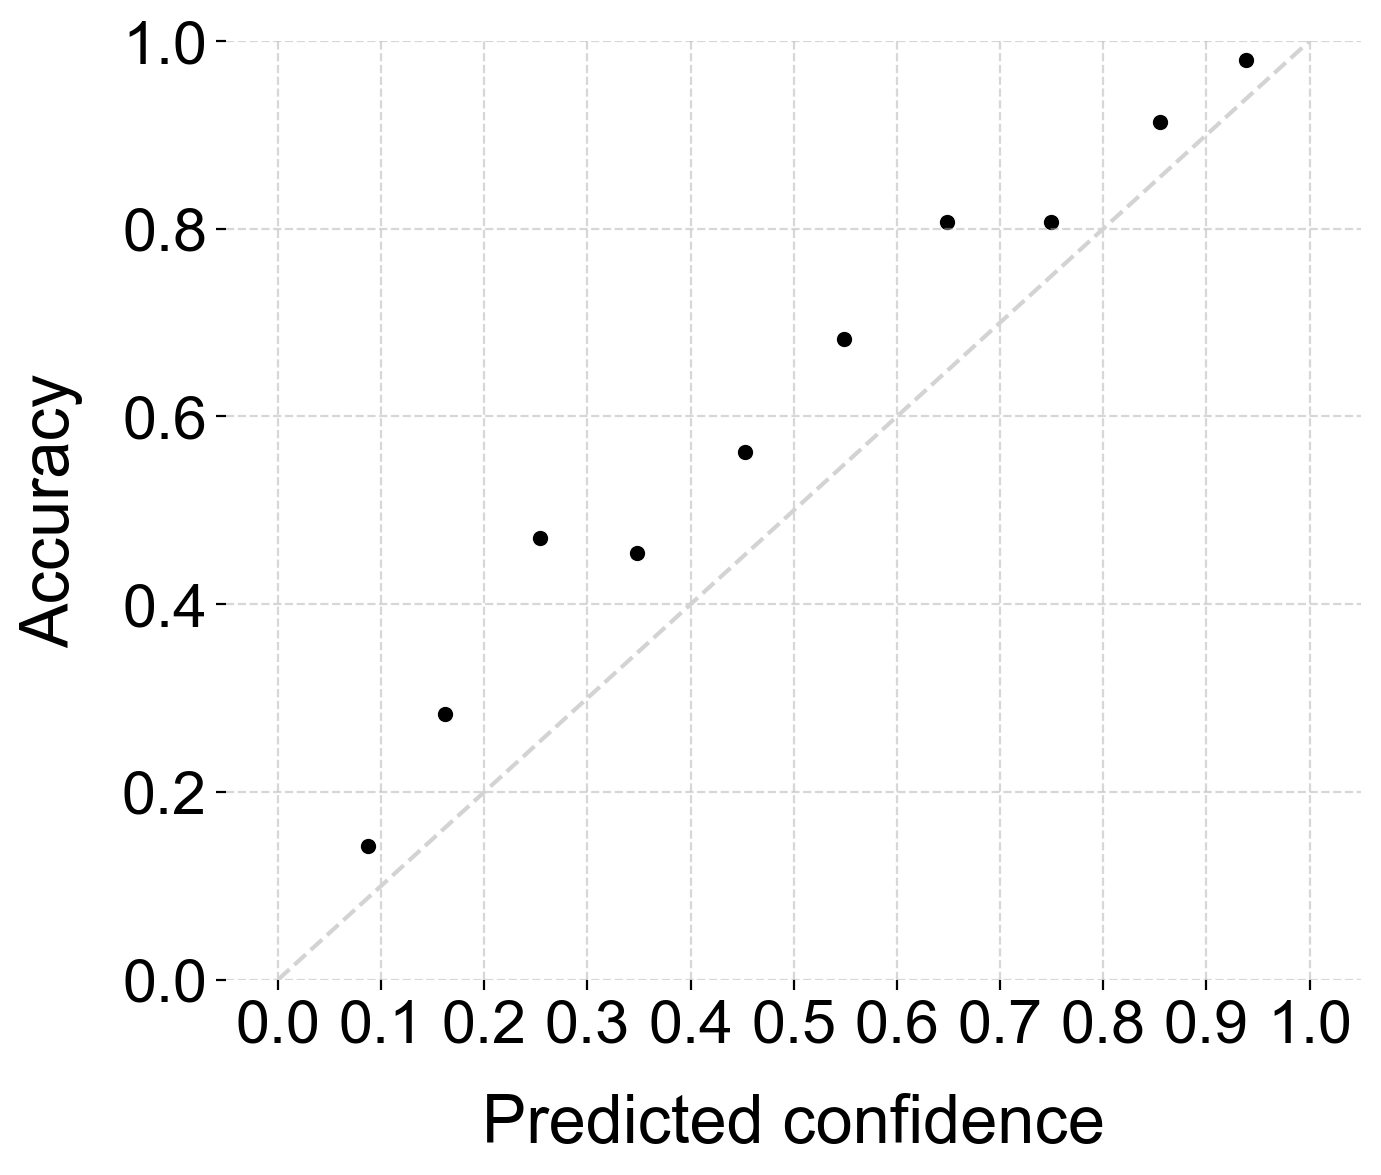

In [294]:
ukhd_preds_df = ukhd_preds.predictions
ukhd_preds_df["y_max_bin"] = pd.cut(
    ukhd_preds_df["top1_conf"],
    bins=[i / 10 for i in range(11)],
    labels=[f"{i/10}-{(i+1)/10}" for i in range(10)],
    include_lowest=True,
)  # binning confidence values

avg_conf_bins = (
    ukhd_preds_df.groupby("y_max_bin", observed=False)["top1_conf"]
    .mean()
    .reset_index(name="mean_conf")
)  # calculate average confidence in each bin
acc_bins = (
    ukhd_preds_df.groupby("y_max_bin", observed=False)
    .apply(lambda x: (x["labels"] == x["pred1"]).mean(), include_groups=False)
    .reset_index(name="accuracy")
)  # calculate accuracy in each bin
acc_conf_bins = pd.merge(avg_conf_bins, acc_bins, on="y_max_bin", how="left")
mpl.rcParams['pdf.fonttype'] = 42
plt.figure(figsize=(7, 6))
plt.rcParams["font.family"] = "Arial"
sns.scatterplot(x=acc_conf_bins["mean_conf"], y=acc_conf_bins["accuracy"], color="k")
plt.xlabel("Predicted confidence", fontsize=24, labelpad=14)
plt.ylabel("Accuracy", fontsize=24, labelpad=14)
plt.xticks(
    np.arange(0, 1.1, 0.1),
    fontsize=22,
)
plt.yticks(fontsize=22)
plt.ylim(0, 1)
plt.plot([0, 1], [0, 1], linestyle="--", color="lightgray")
plt.box(False)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 2d: Distribution of predicted confidence


y_max_bin
0.0-0.1      7
0.1-0.2     53
0.2-0.3     68
0.3-0.4     99
0.4-0.5    112
0.5-0.6     82
0.6-0.7    114
0.7-0.8    119
0.8-0.9    197
0.9-1.0    251
Name: count, dtype: int64


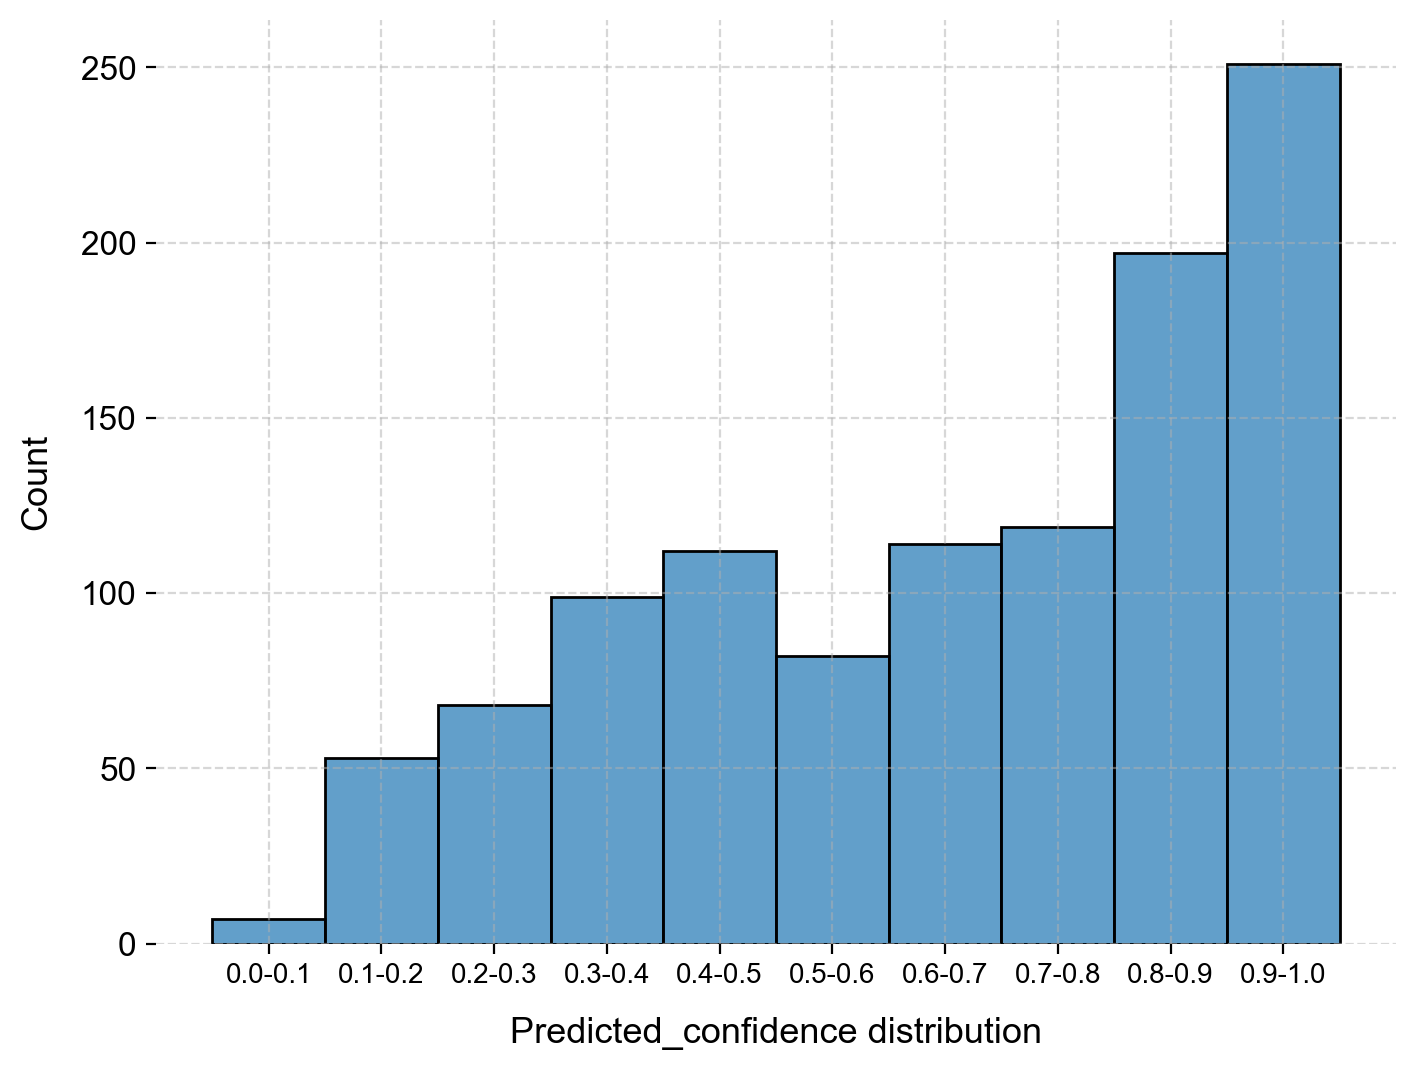

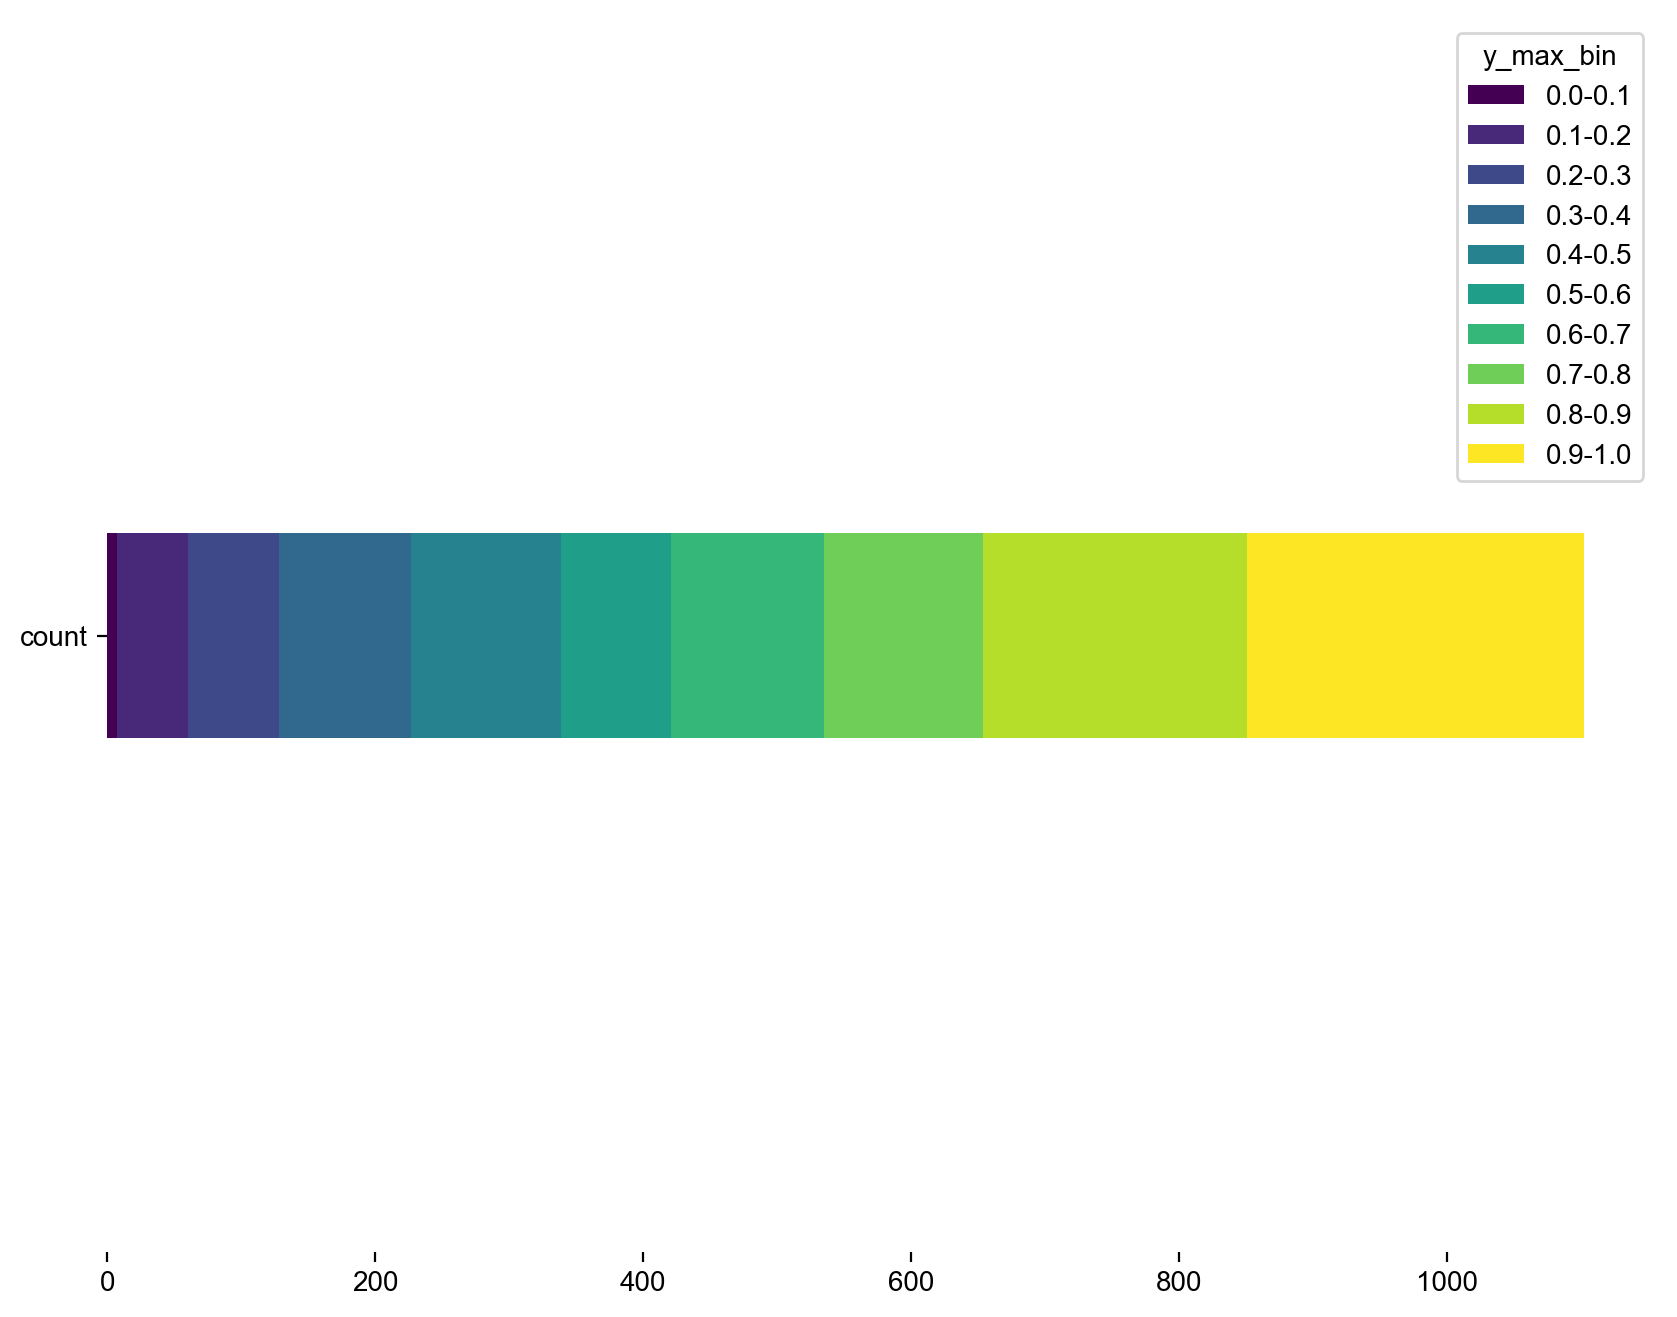

In [295]:
ukhd_confidence = (
    ukhd_preds.plot_confidence_distribution()
)  # get confidence distribution (pd.series)

conf_df = pd.DataFrame(ukhd_confidence).T
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(conf_df.columns)))
conf_df.plot(kind="barh", stacked=True, color=colors, width=0.1, figsize=(10, 8))
mpl.rcParams['pdf.fonttype'] = 42
plt.box(False)
plt.show()

## Figure 2d: Sankey plot for the internal validation


In [296]:
# =============================================================================
# Helper: generate Sankey diagram input .txt files
# =============================================================================
def sankey_inputs_convert(pred_df, output_path, color_ref, include_colors=True):
    """
    Args:
        pred_df:        DataFrame with columns 'true_abbr' and 'pred_abbr'.
        output_path:    Path to output .txt file.
        color_ref:      Dict mapping abbreviation -> hex color string.
        include_colors: If True, prepend colour-definition lines.
    """
    labels = pred_df["true_abbr"].unique()
    with open(output_path, "w") as f:
        if include_colors:
            all_abbr = set(labels) | set(pred_df["pred_abbr"].unique())
            for item in sorted(all_abbr):
                if item in color_ref:
                    f.write(f":{item} {color_ref[item][:7]}\n")
                    f.write(f":{item}_pred {color_ref[item][:7]}\n")
        for item in labels:
            sub_df = pred_df[pred_df["true_abbr"] == item]
            count = sub_df["pred_abbr"].value_counts()
            for key, value in count.items():
                f.write(f"{item} [{value}] {key}_pred\n")


In [297]:
high_conf_preds = ukhd_preds.filter_methy_preds_confidence(p_threshold=0.5).copy()
high_conf_preds["true_abbr"] = high_conf_preds["class"].map(
    ukhd_preds.extra_info.set_index("Class")["Abbr_class"]
)
high_conf_preds["pred_abbr"] = (
    high_conf_preds["pred1"]
    .map(ukhd_preds.int2str_mapping)
    .map(ukhd_preds.extra_info.set_index("Class")["Abbr_class"])
)
high_conf_preds["label_sf"] = high_conf_preds["labels"].map(
    ukhd_preds.extra_info.set_index("label_class")["label_sf"]
)
high_conf_preds.sort_values(["label_sf", "labels", "pred1"], inplace=True)
color_mapping = ukhd_preds.extra_info.set_index("Abbr_class")[
    "color_code_class"
].to_dict()

sankey_inputs_convert(
    high_conf_preds, "sankey_plot_data_high_conf_ukhd.txt", color_mapping
)  # convert data to needed format then generate sankeyplots through https://sankeymatic.com/build/
# generate sankey plots for low confidence samples in the same way


## Figure 2e: Training sample size vs predicted confidence


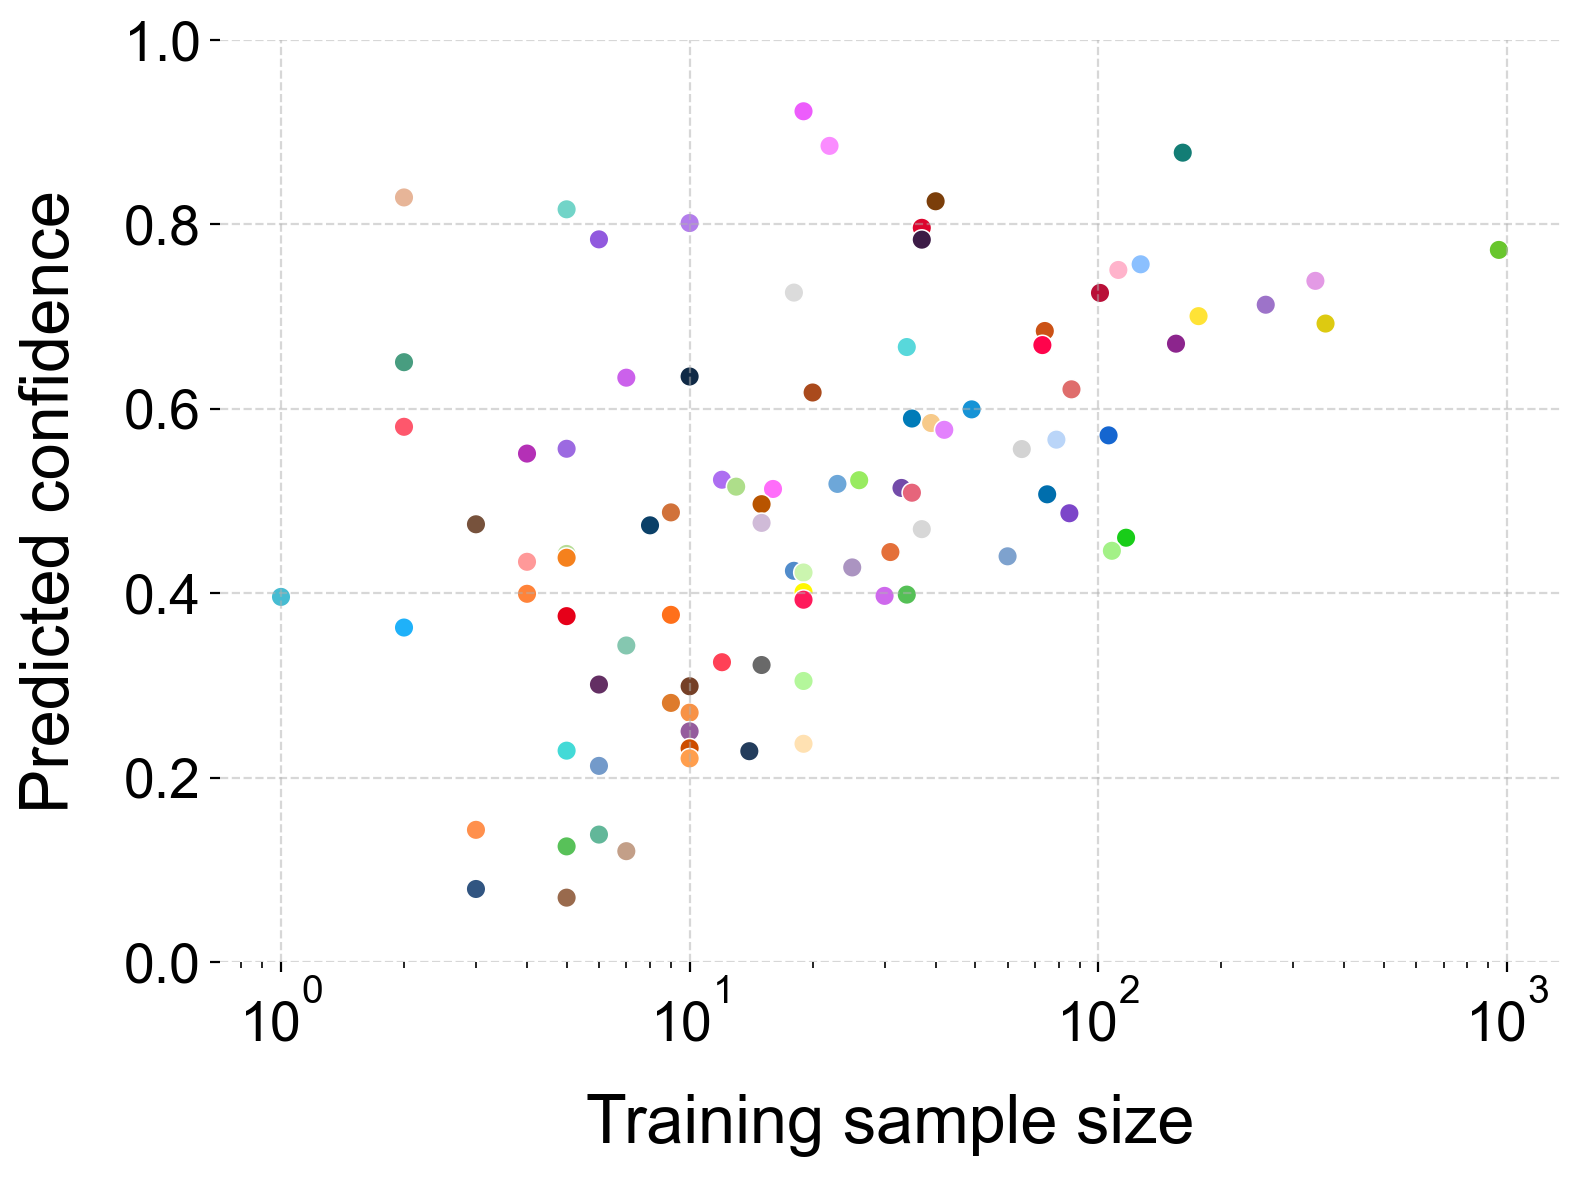

In [298]:
with open(SPLIT_FILE, "r") as fid:  # read data split file
    train_id = yaml.safe_load(fid)["train"]

label_file = ukhd_preds.label_file.copy()
label_file = label_file[label_file["slide_ID"].isin(train_id)]

train_count = (
    label_file.groupby("class")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)  # training sample size for each tumor type
cls_conf = (
    ukhd_preds_df.groupby("class")["top1_conf"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)  # avg confidence for each tumor type
count_conf = pd.merge(cls_conf, train_count, on="class", how="left")

color_mapping = ukhd_preds.get_color_mapping()
mpl.rcParams['pdf.fonttype'] = 42
plt.figure(figsize=(8, 6))
plt.rcParams["font.family"] = "Arial"
scatter_plot = sns.scatterplot(
    x=count_conf["count"],
    y=count_conf["top1_conf"],
    hue=count_conf["class"],
    palette=color_mapping,
    s=50,
    legend=False,
)  #
scatter_plot.set_xscale("log")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0, 1)
plt.xlabel("Training sample size", fontsize=24, labelpad=15)
plt.ylabel("Predicted confidence", fontsize=24, labelpad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.box(False)
plt.tight_layout()
plt.show()

## Figure 3: Confusion matrix for internal validation

/var/folders/fj/2mkb2fwd27x3yb8l_fcvb6c80000gs/T/ipykernel_4489/3357457507.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


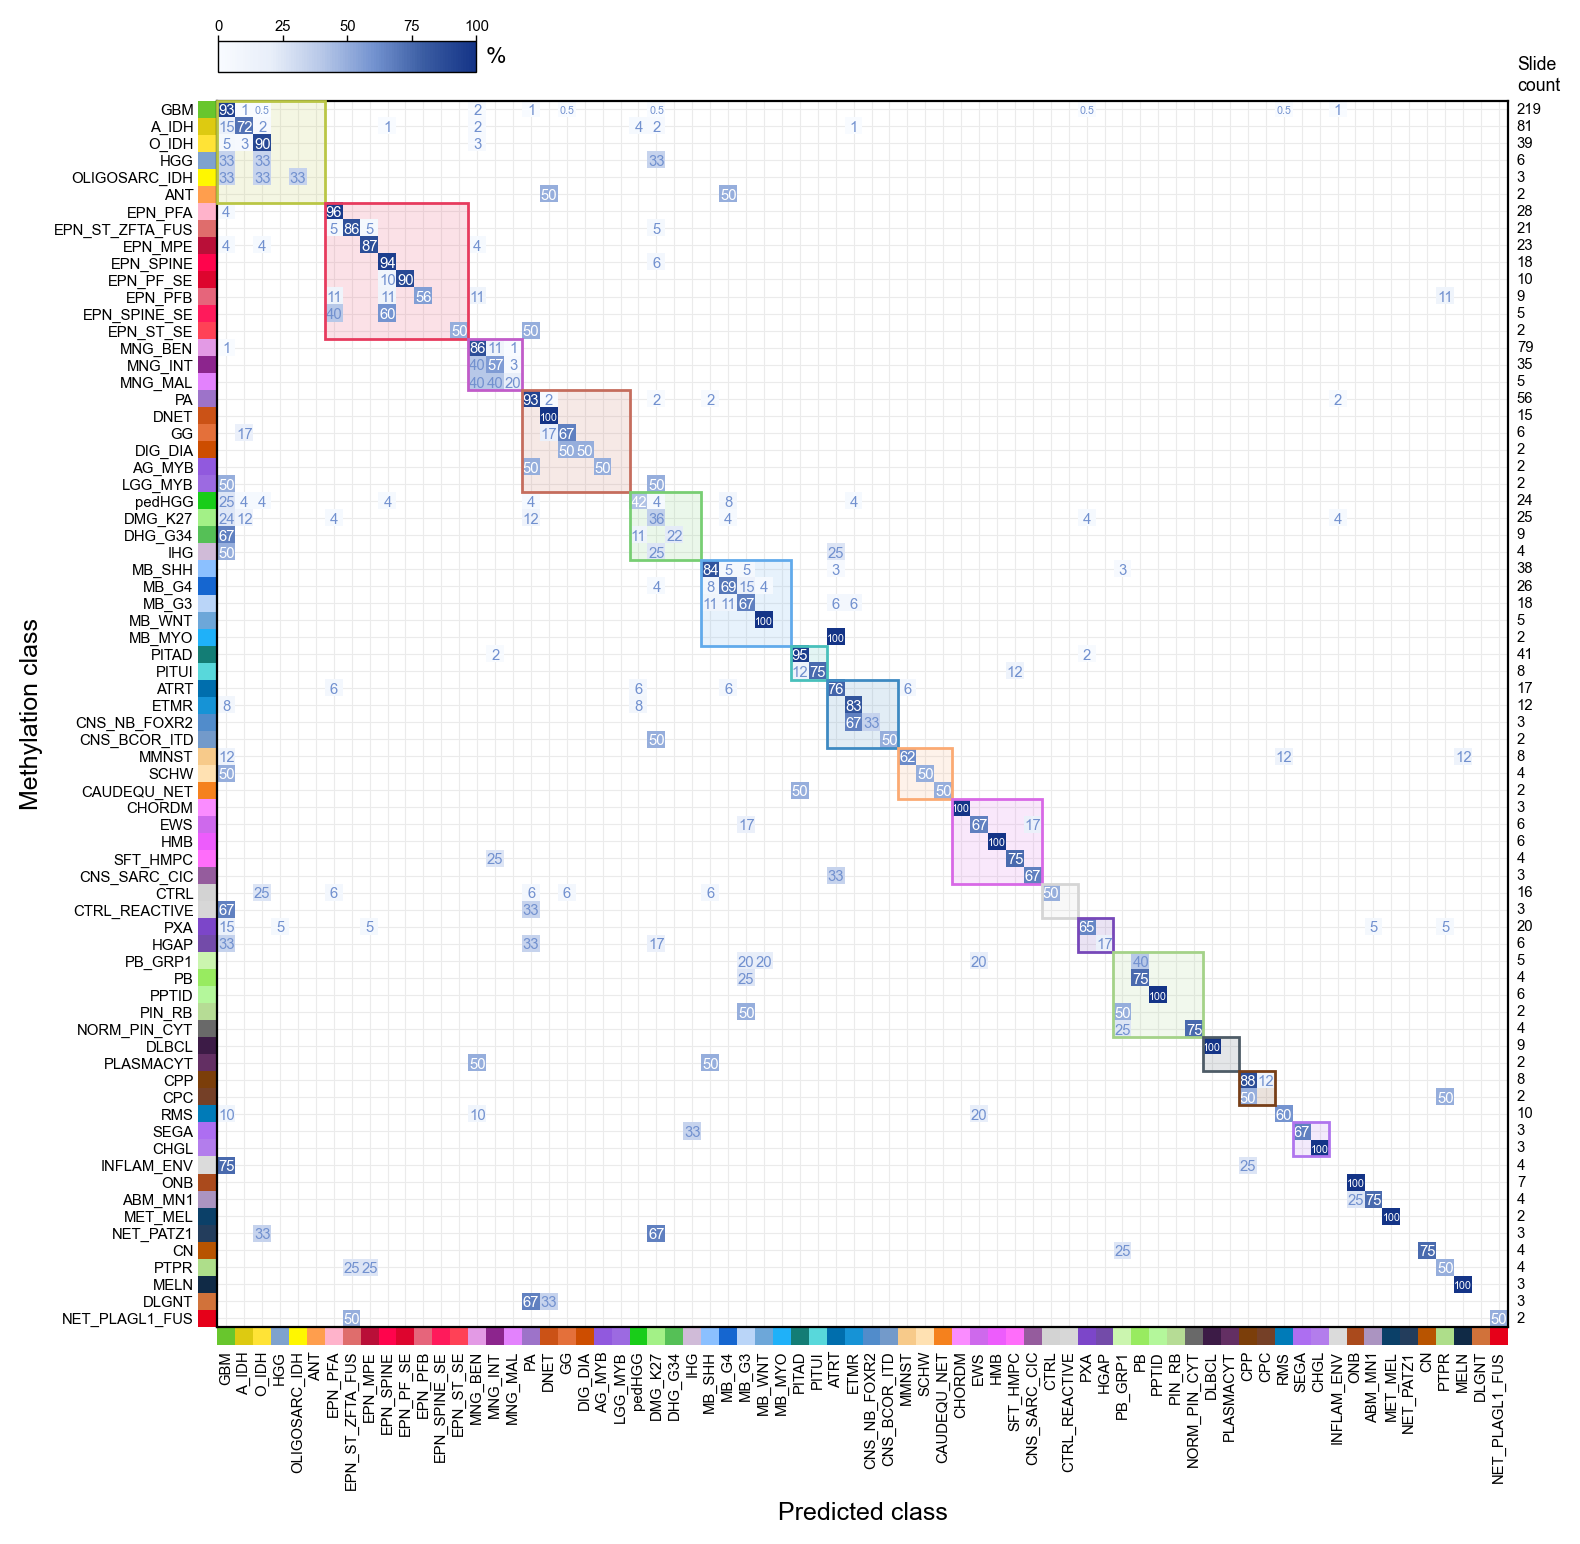

In [299]:
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def get_dkfz_colormap(n_bins=100):
    """Create DKFZ colormap with white for NaN values."""
    colors = np.array([
        [248, 251, 255], 
        [232, 238, 249],
        [182, 199, 231.5], 
        [116, 147, 208], 
        [58, 92, 162], 
        [20, 52, 135]
    ])
    cmap = LinearSegmentedColormap.from_list('dkfz', colors / 255, N=n_bins)
    cmap.set_bad(color=(1, 1, 1, 0))
    return cmap

extra_info = ukhd_preds.extra_info
predictions = ukhd_preds.predictions

# Prepare data
labels = predictions['labels']
preds = predictions['pred1']
ordered_labels = extra_info['label_class'].tolist()
tumor_name_ls = extra_info['Abbr_class']
color_ls = extra_info['color_code_class'].str.strip()
superfamily_colour = extra_info['color_code_sf'].str.strip()

# Create and filter confusion matrix
cm = confusion_matrix(labels, preds, labels=ordered_labels)
sample_counts_per_class = cm.sum(axis=1)
mask = sample_counts_per_class > 1

cm_unpooled = cm[mask][:, mask]
tumor_ls = tumor_name_ls[mask]
color_ls = color_ls[mask]
superfamily_colour = superfamily_colour[mask]

# Normalize confusion matrix
cm_normalized = cm_unpooled.copy() / cm_unpooled.sum(1, keepdims=True)
cm_normalized[cm_normalized == 0] = np.nan

# Create figure and plot heatmap
colormap = get_dkfz_colormap()
f_size = 5.35
fig, ax = plt.subplots(figsize=(8, 8))
mpl.rcParams['pdf.fonttype'] = 42
im = ax.imshow(cm_normalized, interpolation='nearest', aspect=0.95, cmap=colormap, zorder=3)

# Configure axes
ax.set_xticks(np.arange(len(tumor_ls)))
ax.set_yticks(np.arange(len(tumor_ls)))
ax.set_xticklabels(tumor_ls, rotation=90, fontsize=f_size, fontdict={'family': 'Arial'})
ax.set_yticklabels(tumor_ls, fontsize=f_size, fontdict={'family': 'Arial'})
ax.set_xlabel('Predicted class', fontsize=9, fontdict={'family': 'Arial'})
ax.set_ylabel('Methylation class', fontsize=9, fontdict={'family': 'Arial'})
ax.grid(which='minor', color='white', linestyle='-', linewidth=0.3)

# Add percentage labels to cells
for i in range(len(tumor_ls)):
    for j in range(len(tumor_ls)):
        value = cm_normalized[i, j] * 100
        if not np.isnan(value):
            color = 'w' if value > 40 else get_dkfz_colormap(100)(0.6)
            
            if value == 100:
                text_str = "%.0f" % value
                x_offset, size = 0, f_size - 1.5
            elif value > 0.5:
                text_str = "%.0f" % value
                x_offset, size = 0.01, f_size
            else:
                text_str = ("%.1f" % value).lstrip('1')
                x_offset, size = 0.01, f_size - 1.5
            
            ax.text(j + x_offset, i + 0.08, text_str, ha='center', va='center', 
                   color=color, fontsize=size, fontdict={'family': 'Arial'}, zorder=5)

# Add sample counts column
sample_counts = np.nansum(cm_unpooled, axis=1)
ax.text(cm_normalized.shape[1], -2.0, 'Slide\ncount', va='center', 
       fontsize=f_size + 1.0, fontdict={'family': 'Arial'}, ha='left')
for i, count in enumerate(sample_counts):
    ax.text(cm_normalized.shape[1], i, str(count), va='center', 
           fontsize=f_size, fontdict={'family': 'Arial'}, ha='left')

# Add class color patches (left and bottom)
patch_width = 1.0
patch_x = -1.5
for i, color in enumerate(color_ls):
    # Left side
    rect = Rectangle((patch_x - 0.05, i - 0.5), patch_width, 1, 
                    linewidth=0, edgecolor='none', facecolor=color, clip_on=False)
    ax.add_patch(rect)
    # Bottom
    rect = Rectangle((i - 0.5, cm_normalized.shape[0] - patch_x - 1.95), 1, patch_width, 
                    linewidth=0, edgecolor='none', facecolor=color, clip_on=False)
    ax.add_patch(rect)

# Add superfamily rectangles
superfamily_groups = []
cur_idx = 0
cur_col = superfamily_colour[0]
for num, col in enumerate(superfamily_colour):
    if col != cur_col:
        superfamily_groups.append((cur_idx, num, cur_col))
        cur_idx = num
        cur_col = col
superfamily_groups.append((cur_idx, num + 1, cur_col))

for start, stop, col in superfamily_groups:
    size = stop - start
    if size > 1:
        rgba_col = to_rgba(col)[:3] + (0.15,)
        # Border
        rect = Rectangle((start - 0.5, start - 0.5), size, size, 
                        linewidth=1, edgecolor=col, facecolor='none', 
                        clip_on=False, zorder=10)
        ax.add_patch(rect)
        # Fill
        rect = Rectangle((start - 0.5, start - 0.5), size, size, 
                        linewidth=1, edgecolor='none', facecolor=rgba_col, clip_on=False)
        ax.add_patch(rect)

# Configure grid and styling
ax.tick_params(which='minor', bottom=False, left=False)
plt.grid(which='major', axis='both', linestyle='-', color=(0.92, 0.92, 0.92), 
        linewidth=0.4, zorder=-4)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_zorder(4)
ax.tick_params(axis='both', which='major', pad=5)

# Add colorbar
cbar_ax = inset_axes(ax, width="20%", height="2.5%", loc='upper left', 
                    bbox_to_anchor=(-0.01, 0.06, 1, 1), bbox_transform=ax.transAxes)
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.outline.set_linewidth(0.5)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=f_size, width=0.5, length=2)
cbar.ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
cbar.ax.set_xticklabels(['0', '25', '50', '75', '100'], fontdict={'family': 'Arial'})
cbar.ax.text(1.075, 0.5, '%', ha='center', va='center', 
            fontsize=f_size + 3, fontdict={'family': 'Arial'})
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.5)
cbar.ax.tick_params(axis='both', which='major', pad=0.7)

# Save and show
fig.tight_layout()
plt.show()

## Figure 4b: Class distribution of external validation and UKHD dataset


In [300]:
# Load predictions of external validation datasets

ucl_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_ucl_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "UCL_labels.csv"),
)
giessen_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_giessen_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "Giessen_labels.csv"),
)
paris_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_paris_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "Paris_labels.csv"),
)
charite_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_charite_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "Charite_labels.csv"),
)
frankfurt_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_frankfurt_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "Frankfurt_labels.csv"),
)
brazil_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_brazil_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "Brazil_labels.csv"),
)
china_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_chongqing_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "Chongqing_labels.csv"),
)
gbm_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_tcga_gbm_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "TCGA_labels.csv"),
)
lgg_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_tcga_lgg_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "TCGA_labels.csv"),
)
chile_prediction = Predictions(
    os.path.join(PREDICTIONS_DIR, "avg_chile_preds.h5"),
    label_file_path=os.path.join(LABEL_DIR, "Chile_labels.csv"),
)

In [301]:
### filter predictions with confidence threshold 0.8
filtered_ucl = ucl_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_paris = paris_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_giessen = giessen_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_charite = charite_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_frankfurt = frankfurt_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_brazil = brazil_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_china = china_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_gbm = gbm_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_lgg = lgg_prediction.filter_methy_preds_confidence(0.8, 0.0)
filtered_chile = chile_prediction.filter_methy_preds_confidence(0.8, 0.0)

external_preds = pd.concat(
    [
        filtered_ucl,
        filtered_giessen,
        filtered_paris,
        filtered_charite,
        filtered_frankfurt,
        filtered_brazil,
        filtered_china,
        filtered_gbm,
        filtered_lgg,
        filtered_chile,
    ],
    axis=0,
)  ## merge all external validation predictions

## Extended data figure 5d: sankey plot and accuracy analysis

In [302]:
all_external_preds = pd.concat(
    [ucl_prediction.predictions, 
     giessen_prediction.predictions, 
     paris_prediction.predictions, 
     charite_prediction.predictions, 
     frankfurt_prediction.predictions, 
     brazil_prediction.predictions, 
     china_prediction.predictions, 
     gbm_prediction.predictions, 
     lgg_prediction.predictions, 
     chile_prediction.predictions]
)

non_high_mc_samples = all_external_preds[~all_external_preds['slide_ID'].isin(external_preds['slide_ID'])]
low_mc_samples = non_high_mc_samples.dropna(subset=['MC_score'])  # remove samples with no methylation score

In [303]:
print("Total number of samples of low methylation score: ", low_mc_samples.shape[0])
print("Correct top1 prediction: ", (low_mc_samples['labels']==low_mc_samples['pred1']).sum())
print("Correct top3 prediction: ", low_mc_samples.top3_match.sum())
print("Average methylation score of low methylation score samples: ", low_mc_samples.MC_score.mean())

Total number of samples of low methylation score:  592
Correct top1 prediction:  179
Correct top3 prediction:  311
Average methylation score of low methylation score samples:  0.45105240595608104


In [304]:
high_conf_low_mc_samples = low_mc_samples[low_mc_samples.top1_conf>0.5]
low_conf_low_mc_samples = low_mc_samples[low_mc_samples.top1_conf<=0.5]
print("Number of low methylation score samples with high confidence: ", high_conf_low_mc_samples.shape[0])
print("Number of low methylation score samples with low confidence: ", low_conf_low_mc_samples.shape[0], "\n")

print("Correct top1 predictions in high confidence subset: ", (high_conf_low_mc_samples['labels']==high_conf_low_mc_samples['pred1']).sum())
print("Correct top3 predictions in high confidence subset: ", high_conf_low_mc_samples.top3_match.sum(), "\n")

print("Correct top1 predictions in low confidence subset: ", (low_conf_low_mc_samples['labels']==low_conf_low_mc_samples['pred1']).sum())
print("Correct top3 predictions in low confidence subset: ", low_conf_low_mc_samples.top3_match.sum())

Number of low methylation score samples with high confidence:  219
Number of low methylation score samples with low confidence:  373 

Correct top1 predictions in high confidence subset:  109
Correct top3 predictions in high confidence subset:  150 

Correct top1 predictions in low confidence subset:  70
Correct top3 predictions in low confidence subset:  161


In [305]:
# label to superfamily mapping
label_sf_map = ukhd_preds.extra_info.set_index('label_class')['label_sf']

# get superfamily-level predictions and labels
def add_superfamily_cols(df):
    df = df.copy()  
    for col in ['labels', 'pred1', 'pred2', 'pred3']:
        df[f'{col.replace("labels", "sf_label").replace("pred", "top" + col[-1] + "_sf_pred")}'[:-1] 
          if col.startswith('pred') else 'sf_label'] = df[col].map(label_sf_map)

    df['top3_sf_match'] = df.apply(
        lambda x: int(x['sf_label'] in [x['top1_sf_pred'], x['top2_sf_pred'], x['top3_sf_pred']]), axis=1
    )
    return df

high_conf_low_mc_samples = add_superfamily_cols(high_conf_low_mc_samples)
low_conf_low_mc_samples = add_superfamily_cols(low_conf_low_mc_samples)

In [306]:
high_conf_low_mc_top1_mispredictions = high_conf_low_mc_samples[high_conf_low_mc_samples['labels']!=high_conf_low_mc_samples['pred1']]
low_conf_low_mc_top1_mispredictions = low_conf_low_mc_samples[low_conf_low_mc_samples['labels']!=low_conf_low_mc_samples['pred1']]
high_conf_low_mc_top3_mispredictions = high_conf_low_mc_samples[high_conf_low_mc_samples['top3_match']!=1]
low_conf_low_mc_top3_mispredictions = low_conf_low_mc_samples[low_conf_low_mc_samples['top3_match']!=1]

In [307]:
print("High confidence intra-superfamily top1 mispredictions: ", (high_conf_low_mc_top1_mispredictions['sf_label']==high_conf_low_mc_top1_mispredictions['top1_sf_pred']).sum())
print("High confidence inter-superfamily top1 mispredictions: ", (high_conf_low_mc_top1_mispredictions['sf_label']!=high_conf_low_mc_top1_mispredictions['top1_sf_pred']).sum(), '\n')

print("High confidence intra-superfamily top3 mispredictions: ", (high_conf_low_mc_top3_mispredictions['top3_sf_match']==1).sum())
print("High confidence inter-superfamily top3 mispredictions: ", (high_conf_low_mc_top3_mispredictions['top3_sf_match']!=1).sum())

High confidence intra-superfamily top1 mispredictions:  49
High confidence inter-superfamily top1 mispredictions:  61 

High confidence intra-superfamily top3 mispredictions:  35
High confidence inter-superfamily top3 mispredictions:  34


In [308]:
print("Low confidence intra-superfamily top1 mispredictions: ", (low_conf_low_mc_top1_mispredictions['sf_label']==low_conf_low_mc_top1_mispredictions['top1_sf_pred']).sum())
print("Low confidence inter-superfamily top1 mispredictions: ", (low_conf_low_mc_top1_mispredictions['sf_label']!=low_conf_low_mc_top1_mispredictions['top1_sf_pred']).sum(), '\n')


print("Low confidence intra-superfamily top3 mispredictions: ", (low_conf_low_mc_top3_mispredictions['top3_sf_match']==1).sum())
print("Low confidence inter-superfamily top3 mispredictions: ", (low_conf_low_mc_top3_mispredictions['top3_sf_match']!=1).sum())

Low confidence intra-superfamily top1 mispredictions:  81
Low confidence inter-superfamily top1 mispredictions:  222 

Low confidence intra-superfamily top3 mispredictions:  78
Low confidence inter-superfamily top3 mispredictions:  134


In [309]:
high_conf_low_mc_samples["true_abbr"] = high_conf_low_mc_samples["class"].map(
    ukhd_preds.extra_info.set_index("Class")["Abbr_class"]
)
high_conf_low_mc_samples["pred_abbr"] = (
    high_conf_low_mc_samples["pred1"]
    .map(ukhd_preds.int2str_mapping)
    .map(ukhd_preds.extra_info.set_index("Class")["Abbr_class"])
)
high_conf_low_mc_samples["label_sf"] = high_conf_low_mc_samples["labels"].map(
    ukhd_preds.extra_info.set_index("label_class")["label_sf"]
)
high_conf_low_mc_samples.sort_values(["label_sf", "labels", "pred1"], inplace=True)
color_mapping = ukhd_preds.extra_info.set_index("Abbr_class")[
    "color_code_class"
].to_dict()

sankey_inputs_convert(
    high_conf_low_mc_samples, "sankey_plot_data_high_conf_low_mc_external_data.txt", color_mapping
) 

In [310]:
low_conf_low_mc_samples["true_abbr"] = low_conf_low_mc_samples["class"].map(
    ukhd_preds.extra_info.set_index("Class")["Abbr_class"]
)
low_conf_low_mc_samples["pred_abbr"] = (
    low_conf_low_mc_samples["pred1"]
    .map(ukhd_preds.int2str_mapping)
    .map(ukhd_preds.extra_info.set_index("Class")["Abbr_class"])
)
low_conf_low_mc_samples["label_sf"] = low_conf_low_mc_samples["labels"].map(
    ukhd_preds.extra_info.set_index("label_class")["label_sf"]
)
low_conf_low_mc_samples.sort_values(["label_sf", "labels", "pred1"], inplace=True)
low_conf_low_mc_samples['true_abbr'] = low_conf_low_mc_samples['true_abbr'].fillna('Retinoblastoma')

sankey_inputs_convert(
    low_conf_low_mc_samples, "sankey_plot_data_low_conf_low_mc_external_data.txt", color_mapping
) 

## Figure 4b: External distribution vs. UKHD distribution

In [311]:
### filter predictions with confidence threshold 0.8
filtered_ucl_ = ucl_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_paris_ = paris_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_giessen_ = giessen_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_charite_ = charite_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_frankfurt_ = frankfurt_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_brazil_ = brazil_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_china_ = china_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_gbm_ = gbm_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_lgg_ = lgg_prediction.filter_methy_preds_confidence(0.0, 0.0)
filtered_chile_ = chile_prediction.filter_methy_preds_confidence(0.0, 0.0)

external_preds_ = pd.concat(
    [
        filtered_ucl_,
        filtered_giessen_,
        filtered_paris_,
        filtered_charite_,
        filtered_frankfurt_,
        filtered_brazil_,
        filtered_china_,
        filtered_gbm_,
        filtered_lgg_,
        filtered_chile_,
    ],
    axis=0,
)  ## merge all external validation predictions

In [312]:
ext_distribution = (
    external_preds["class"].value_counts().reset_index()
)  # get distribution of tumor types in external validation datasets
ext_distribution["freq_ext"] = (
    ext_distribution["count"] / ext_distribution["count"].sum()
)  # calculate frequency of each tumor type

int_distribution = (
    ukhd_preds.predictions["class"].value_counts().reset_index()
)  # get distribution of tumor types in UKHD dataset
int_distribution["freq_int"] = (
    int_distribution["count"] / int_distribution["count"].sum()
)  # calculate frequency of each tumor type
int_distribution["Abbr_class"] = int_distribution["class"].apply(
    lambda x: ukhd_preds.extra_info[ukhd_preds.extra_info["Class"] == x][
        "Abbr_class"
    ].values[0]
)  # get abbrevation of tumor type

In [313]:
all_distribution = pd.merge(
    int_distribution, ext_distribution, on="class", how="left"
)  # merge UKHD and external validation distributions
all_distribution.fillna({"freq_ext": 0}, inplace=True)
all_distribution = pd.merge(
    all_distribution,
    ukhd_preds.extra_info[
        ["Abbr_class", "color_code_class", "label_sf", "label_class"]
    ],
    on="Abbr_class",
    how="left",
)  # merge color code and hierarchy info
all_distribution.sort_values(
    by=["label_sf", "count_x"], ascending=[True, False], inplace=True
)  # sort by hierarchy and UKHD sample size
all_distribution["Color_code"] = all_distribution["color_code_class"].apply(
    lambda x: x[:7]
)

In [314]:
fig, ax = plt.subplots(2, 1, figsize=(80, 16))
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'
custom_palette = all_distribution.set_index('Abbr_class')['Color_code'].to_dict()

sns.barplot(x='Abbr_class', y='count_y', data=all_distribution, hue='Abbr_class', palette=custom_palette, label='ext', legend=False, alpha=0.6, ax=ax[0])  # Distribution of external validation dataset
ax[0].set_title('External validation dataset', fontsize=64, pad=15) # set title for the first subplot

sns.barplot(x='Abbr_class', y='count_x', data=all_distribution, hue='Abbr_class', palette=custom_palette, label='ext', legend=False, alpha=0.6, ax=ax[1])  # Distribution of UKHD dataset
ax[1].set_title('UKHD dataset', fontsize=64, pad=15) # set title for the second subplot

for i in range(2):
    ax[i].set_ylabel('Count', fontsize=72, labelpad=15)
    ax[i].set_xlabel('')
    ax[i].set_xlim(-1, all_distribution.shape[0])
    ax[i].set_yscale('log')
    ax[i].set_xticks(range(all_distribution.shape[0]))
    ax[i].set_xticklabels(all_distribution.Abbr_class, rotation=45, fontsize=32, ha='right')

    ax[i].tick_params(axis='y', labelsize=48)
    ax[i].grid(True, linestyle='--', alpha=0.5)
    for spine in ax[i].spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

## Figure 4d: Sankey diagram for external validation datasets


In [315]:
high_conf_preds = external_preds[external_preds.top1_conf > 0.5].copy()
abbr_mapping = ukhd_preds.extra_info.set_index("Class")["Abbr_class"].to_dict()
high_conf_preds["true_abbr"] = high_conf_preds["class"].map(abbr_mapping)
high_conf_preds["pred_abbr"] = (
    high_conf_preds["pred1"].map(ukhd_preds.int2str_mapping).map(abbr_mapping)
)
high_conf_preds["label_sf"] = high_conf_preds["labels"].map(
    ukhd_preds.extra_info.set_index("label_class")["label_sf"]
)
high_conf_preds.sort_values(["label_sf", "labels", "pred1"], inplace=True)
color_mapping = ukhd_preds.extra_info.set_index("Abbr_class")[
    "color_code_class"
].to_dict()
output_path = "sankey_plot_data_high_conf_external.txt"
sankey_inputs_convert(
    high_conf_preds, output_path, color_mapping
)  # plot low confidence predictions in the same sankey plot as high confidence predictions

## Figure 4e: Delta confidence vs. Delta accuracy (external-UKHD)


In [316]:
ext_conf_df = (
    external_preds.groupby("class")["top1_conf"].mean().reset_index(name="mean_conf")
)
ext_acc_df = (
    external_preds.groupby("class")
    .apply(lambda x: np.mean(x["labels"] == x["pred1"]), include_groups=False)
    .reset_index(name="accuracy")
)
ext_conf_acc = pd.merge(ext_conf_df, ext_acc_df, on="class")

ukhd_preds_df = ukhd_preds.predictions
ukhd_conf_df = (
    ukhd_preds_df.groupby("class")["top1_conf"].mean().reset_index(name="mean_conf")
)
ukhd_acc_df = (
    ukhd_preds_df.groupby("class")
    .apply(lambda x: np.mean(x["labels"] == x["pred1"]), include_groups=False)
    .reset_index(name="accuracy")
)
ukhd_conf_acc = pd.merge(ukhd_conf_df, ukhd_acc_df, on="class")

external_ukhd_df = pd.merge(
    ext_conf_acc, ukhd_conf_acc, on="class", suffixes=("_ext", "_ukhd"), how="left"
)
external_ukhd_df["delta_conf"] = (
    external_ukhd_df["mean_conf_ext"] - external_ukhd_df["mean_conf_ukhd"]
)
external_ukhd_df["delta_acc"] = (
    external_ukhd_df["accuracy_ext"] - external_ukhd_df["accuracy_ukhd"]
)

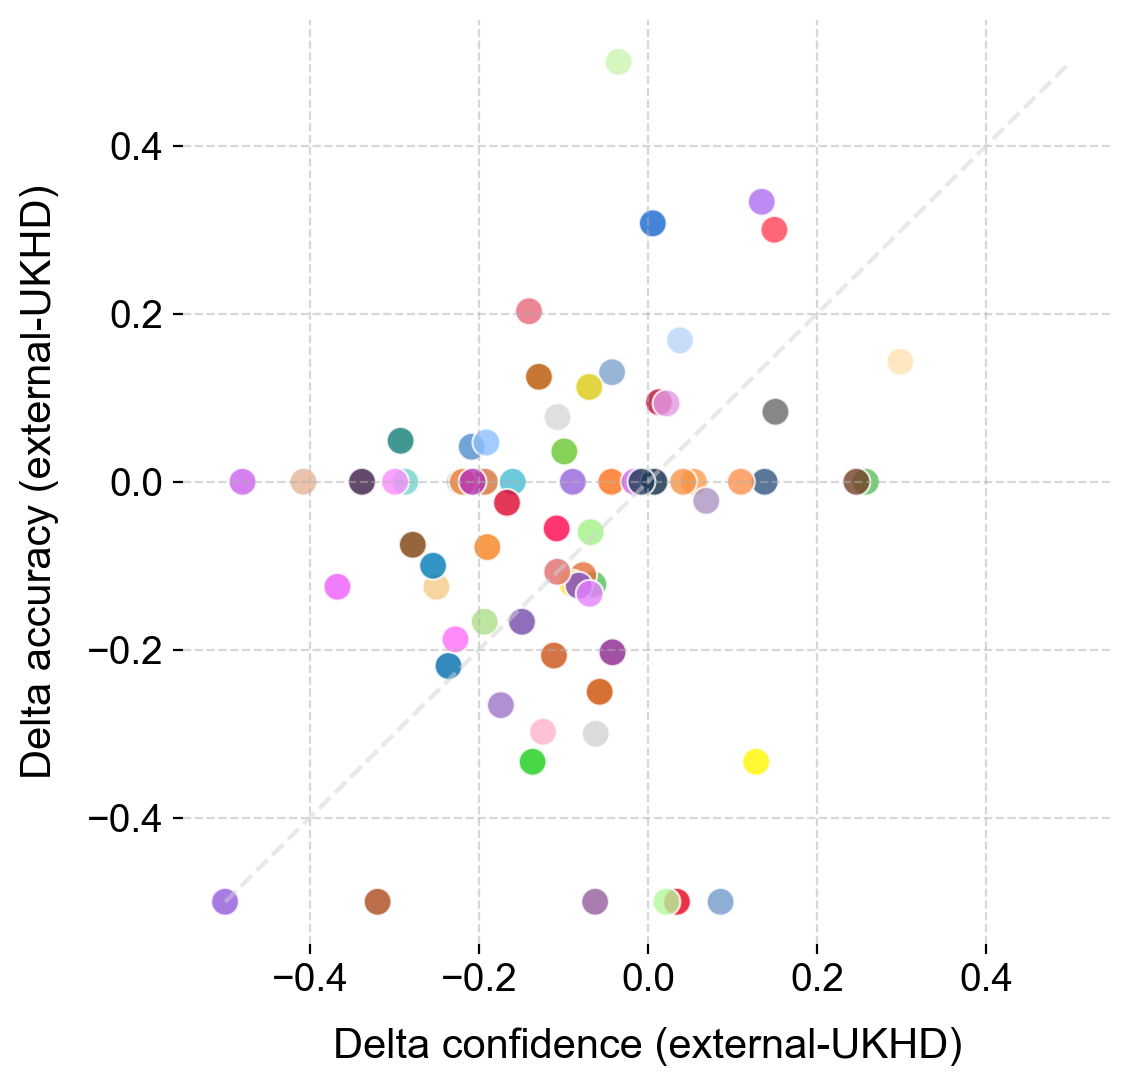

In [317]:
fig, ax = plt.subplots(figsize=(6, 6))
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams["font.family"] = "Arial"
color_mapping = ukhd_preds.get_color_mapping()
external_ukhd_df = external_ukhd_df[
    external_ukhd_df["class"].isin(list(color_mapping.keys()))
]
sns.scatterplot(
    data=external_ukhd_df,
    x="delta_conf",
    y="delta_acc",
    hue="class",
    palette=color_mapping,
    s=100,
    alpha=0.8,
    legend=False,
)
plt.xlabel("Delta confidence (external-UKHD)", fontsize=15, labelpad=10)
plt.ylabel("Delta accuracy (external-UKHD)", fontsize=15, labelpad=10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(-0.55, 0.55)
plt.ylim(-0.55, 0.55)
plt.grid(True, linestyle="--", alpha=0.5)
plt.plot([-0.5, 0.5], [-0.5, 0.5], color="lightgray", linestyle="--", alpha=0.5)
plt.box(False)
plt.show()

## Figure 4f: Predicted confidence vs accuracy w.r.t external validation datasets


In [318]:
ext_val_df = pd.DataFrame(
    {
        "confidence": [
            filtered_ucl["top1_conf"].mean(),
            filtered_paris["top1_conf"].mean(),
            filtered_giessen["top1_conf"].mean(),
            filtered_charite["top1_conf"].mean(),
            filtered_frankfurt["top1_conf"].mean(),
            filtered_brazil["top1_conf"].mean(),
            filtered_china["top1_conf"].mean(),
            filtered_gbm["top1_conf"].mean(),
            filtered_lgg["top1_conf"].mean(),
            filtered_chile["top1_conf"].mean(),
        ],
        "accuracy": [
            (filtered_ucl["labels"] == filtered_ucl["pred1"]).mean(),
            (filtered_paris["labels"] == filtered_paris["pred1"]).mean(),
            (filtered_giessen["labels"] == filtered_giessen["pred1"]).mean(),
            (filtered_charite["labels"] == filtered_charite["pred1"]).mean(),
            (filtered_frankfurt["labels"] == filtered_frankfurt["pred1"]).mean(),
            (filtered_brazil["labels"] == filtered_brazil["pred1"]).mean(),
            (filtered_china["labels"] == filtered_china["pred1"]).mean(),
            (filtered_gbm["labels"] == filtered_gbm["pred1"]).mean(),
            (filtered_lgg["labels"] == filtered_lgg["pred1"]).mean(),
            (filtered_chile["labels"] == filtered_chile["pred1"]).mean(),
        ],
    },
    index=[
        "UCL",
        "Paris",
        "Giessen",
        "Charite",
        "Frankfurt",
        "Brazil",
        "China",
        "TCGA-GBM",
        "TCGA-LGG",
        "Chile",
    ],
)

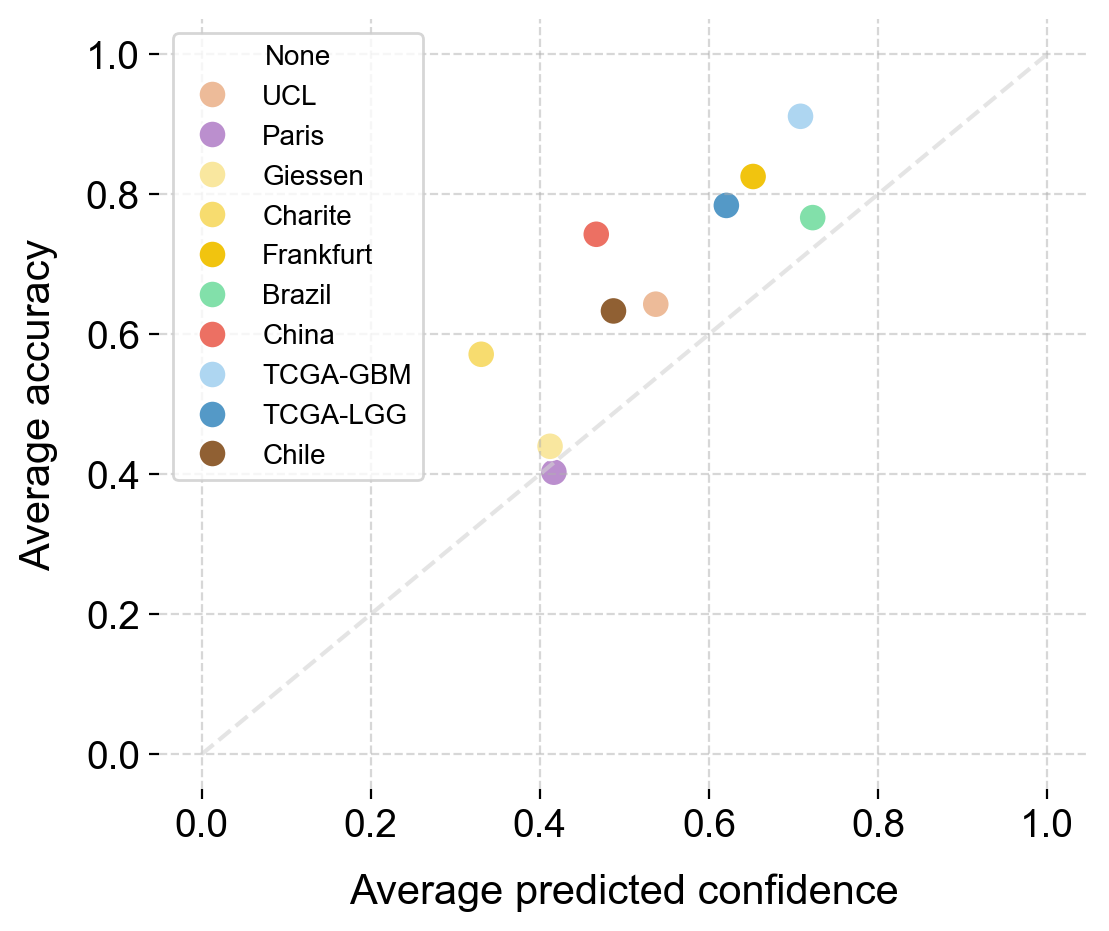

In [319]:
fig, ax = plt.subplots(figsize=(6, 5))
mpl.rcParams['pdf.fonttype'] = 42
customed_palette = {
    "UCL": "#edbb99",
    "Paris": "#bb8fce",
    "Giessen": "#f9e79f",
    "Charite": "#f7dc6f",
    "Frankfurt": "#f1c40f",
    "Brazil": "#82e0aa",
    "China": "#ec7063",
    "TCGA-GBM": "#aed6f1",
    "TCGA-LGG": "#5499c7",
    "Chile": "#906033",
}
plt.rcParams["font.family"] = "Arial"
sns.scatterplot(
    data=ext_val_df,
    x="confidence",
    y="accuracy",
    hue=ext_val_df.index,
    palette=customed_palette,
    s=100,
    legend=True,
)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Average predicted confidence", fontsize=15, labelpad=10)
plt.ylabel("Average accuracy", fontsize=15, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.plot([0, 1], [0, 1], linestyle="--", color="lightgray", alpha=0.6)
plt.box(False)
plt.show()

In [320]:
filtered_ucl_high = filtered_ucl[filtered_ucl["top1_conf"] > 0.5]
filtered_ucl_low = filtered_ucl[filtered_ucl["top1_conf"] <= 0.5]
filtered_paris_high = filtered_paris[filtered_paris["top1_conf"] > 0.5]
filtered_paris_low = filtered_paris[filtered_paris["top1_conf"] <= 0.5]
filtered_giessen_high = filtered_giessen[filtered_giessen["top1_conf"] > 0.5]
filtered_giessen_low = filtered_giessen[filtered_giessen["top1_conf"] <= 0.5]
filtered_charite_high = filtered_charite[filtered_charite["top1_conf"] > 0.5]
filtered_charite_low = filtered_charite[filtered_charite["top1_conf"] <= 0.5]
filtered_frankfurt_high = filtered_frankfurt[filtered_frankfurt["top1_conf"] > 0.5]
filtered_frankfurt_low = filtered_frankfurt[filtered_frankfurt["top1_conf"] <= 0.5]
filtered_brazil_high = filtered_brazil[filtered_brazil["top1_conf"] > 0.5]
filtered_brazil_low = filtered_brazil[filtered_brazil["top1_conf"] <= 0.5]
filtered_china_high = filtered_china[filtered_china["top1_conf"] > 0.5]
filtered_china_low = filtered_china[filtered_china["top1_conf"] <= 0.5]
filtered_gbm_high = filtered_gbm[filtered_gbm["top1_conf"] > 0.5]
filtered_gbm_low = filtered_gbm[filtered_gbm["top1_conf"] <= 0.5]
filtered_lgg_high = filtered_lgg[filtered_lgg["top1_conf"] > 0.5]
filtered_lgg_low = filtered_lgg[filtered_lgg["top1_conf"] <= 0.5]
filtered_chile_high = filtered_chile[filtered_chile["top1_conf"] > 0.5]
filtered_chile_low = filtered_chile[filtered_chile["top1_conf"] <= 0.5]

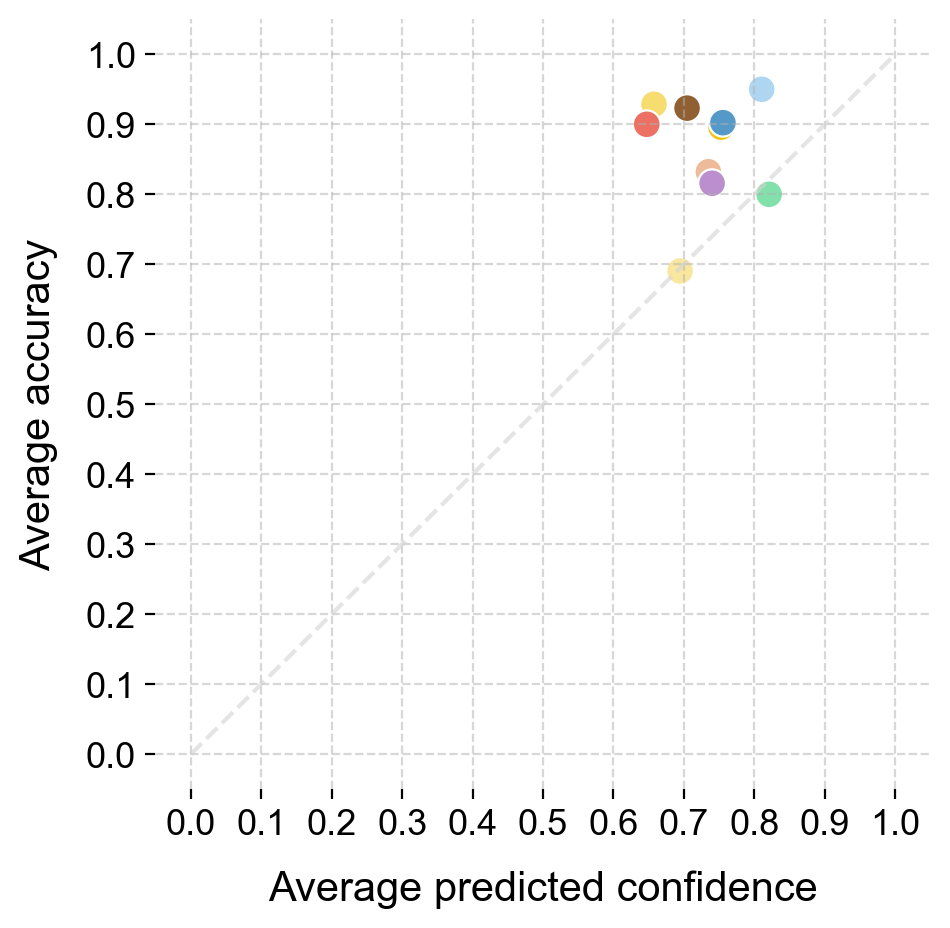

In [321]:
ext_val_df = pd.DataFrame(
    {
        "confidence": [
            filtered_ucl_high["top1_conf"].mean(),
            filtered_paris_high["top1_conf"].mean(),
            filtered_giessen_high["top1_conf"].mean(),
            filtered_charite_high["top1_conf"].mean(),
            filtered_frankfurt_high["top1_conf"].mean(),
            filtered_brazil_high["top1_conf"].mean(),
            filtered_china_high["top1_conf"].mean(),
            filtered_gbm_high["top1_conf"].mean(),
            filtered_lgg_high["top1_conf"].mean(),
            filtered_chile_high["top1_conf"].mean(),
        ],
        "accuracy": [
            (filtered_ucl_high["labels"] == filtered_ucl_high["pred1"]).mean(),
            (filtered_paris_high["labels"] == filtered_paris_high["pred1"]).mean(),
            (filtered_giessen_high["labels"] == filtered_giessen_high["pred1"]).mean(),
            (filtered_charite_high["labels"] == filtered_charite_high["pred1"]).mean(),
            (
                filtered_frankfurt_high["labels"] == filtered_frankfurt_high["pred1"]
            ).mean(),
            (filtered_brazil_high["labels"] == filtered_brazil_high["pred1"]).mean(),
            (filtered_china_high["labels"] == filtered_china_high["pred1"]).mean(),
            (filtered_gbm_high["labels"] == filtered_gbm_high["pred1"]).mean(),
            (filtered_lgg_high["labels"] == filtered_lgg_high["pred1"]).mean(),
            (filtered_chile_high["labels"] == filtered_chile_high["pred1"]).mean(),
        ],
    },
    index=[
        "UCL",
        "Paris",
        "Giessen",
        "Charite",
        "Frankfurt",
        "Brazil",
        "China",
        "TCGA-GBM",
        "TCGA-LGG",
        "Chile",
    ],
)


fig, ax = plt.subplots(figsize=(5, 5))
mpl.rcParams['pdf.fonttype'] = 42
customed_palette = {
    "UCL": "#edbb99",
    "Paris": "#bb8fce",
    "Giessen": "#f9e79f",
    "Charite": "#f7dc6f",
    "Frankfurt": "#f1c40f",
    "Brazil": "#82e0aa",
    "China": "#ec7063",
    "TCGA-GBM": "#aed6f1",
    "TCGA-LGG": "#5499c7",
    "Chile": "#906033",
}
plt.rcParams["font.family"] = "Arial"
sns.scatterplot(
    data=ext_val_df,
    x="confidence",
    y="accuracy",
    hue=ext_val_df.index,
    palette=customed_palette,
    s=100,
    legend=False,
)
plt.xlabel("Average predicted confidence", fontsize=15, labelpad=10)
plt.ylabel("Average accuracy", fontsize=15, labelpad=10)
plt.xticks(np.arange(0., 1.1, 0.1), fontsize=13)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.plot([0., 1], [0., 1], linestyle="--", color="lightgray", alpha=0.6)
plt.box(False)
plt.show()

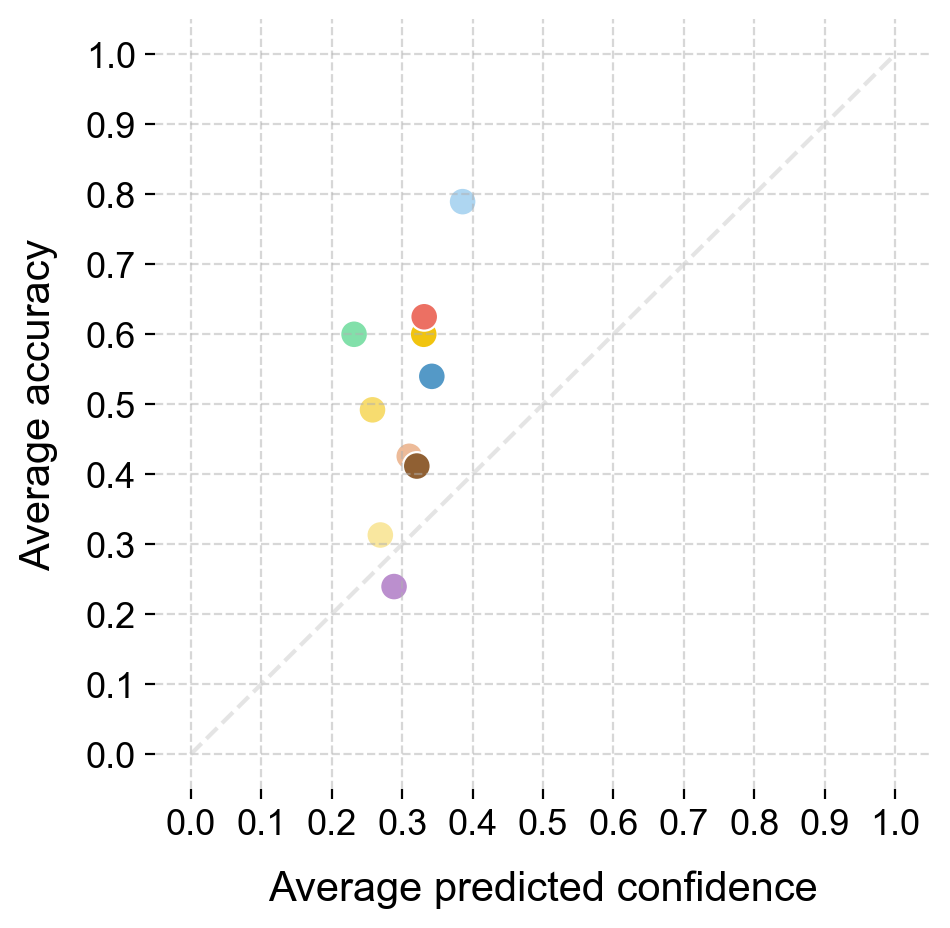

In [322]:
ext_val_df = pd.DataFrame(
    {
        "confidence": [
            filtered_ucl_low["top1_conf"].mean(),
            filtered_paris_low["top1_conf"].mean(),
            filtered_giessen_low["top1_conf"].mean(),
            filtered_charite_low["top1_conf"].mean(),
            filtered_frankfurt_low["top1_conf"].mean(),
            filtered_brazil_low["top1_conf"].mean(),
            filtered_china_low["top1_conf"].mean(),
            filtered_gbm_low["top1_conf"].mean(),
            filtered_lgg_low["top1_conf"].mean(),
            filtered_chile_low["top1_conf"].mean(),
        ],
        "accuracy": [
            (filtered_ucl_low["labels"] == filtered_ucl_low["pred1"]).mean(),
            (filtered_paris_low["labels"] == filtered_paris_low["pred1"]).mean(),
            (filtered_giessen_low["labels"] == filtered_giessen_low["pred1"]).mean(),
            (filtered_charite_low["labels"] == filtered_charite_low["pred1"]).mean(),
            (
                filtered_frankfurt_low["labels"] == filtered_frankfurt_low["pred1"]
            ).mean(),
            (filtered_brazil_low["labels"] == filtered_brazil_low["pred1"]).mean(),
            (filtered_china_low["labels"] == filtered_china_low["pred1"]).mean(),
            (filtered_gbm_low["labels"] == filtered_gbm_low["pred1"]).mean(),
            (filtered_lgg_low["labels"] == filtered_lgg_low["pred1"]).mean(),
            (filtered_chile_low["labels"] == filtered_chile_low["pred1"]).mean(),
        ],
    },
    index=[
        "UCL",
        "Paris",
        "Giessen",
        "Charite",
        "Frankfurt",
        "Brazil",
        "China",
        "TCGA-GBM",
        "TCGA-LGG",
        "Chile",
    ],
)

fig, ax = plt.subplots(figsize=(5, 5))
mpl.rcParams['pdf.fonttype'] = 42
customed_palette = {
    "UCL": "#edbb99",
    "Paris": "#bb8fce",
    "Giessen": "#f9e79f",
    "Charite": "#f7dc6f",
    "Frankfurt": "#f1c40f",
    "Brazil": "#82e0aa",
    "China": "#ec7063",
    "TCGA-GBM": "#aed6f1",
    "TCGA-LGG": "#5499c7",
    "Chile": "#906033",
}
plt.rcParams["font.family"] = "Arial"
sns.scatterplot(
    data=ext_val_df,
    x="confidence",
    y="accuracy",
    hue=ext_val_df.index,
    palette=customed_palette,
    s=100,
    legend=False,
)
plt.xlabel("Average predicted confidence", fontsize=15, labelpad=10)
plt.ylabel("Average accuracy", fontsize=15, labelpad=10)
plt.xticks(np.arange(0., 1.1, 0.1), fontsize=13)
plt.yticks(np.arange(0., 1.1, 0.1), fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.plot([0, 1], [0, 1], linestyle="--", color="lightgray", alpha=0.6)
plt.box(False)
plt.show()

## Extended data figure 3: Confusion matrix for external validation

/var/folders/fj/2mkb2fwd27x3yb8l_fcvb6c80000gs/T/ipykernel_4489/1220457297.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


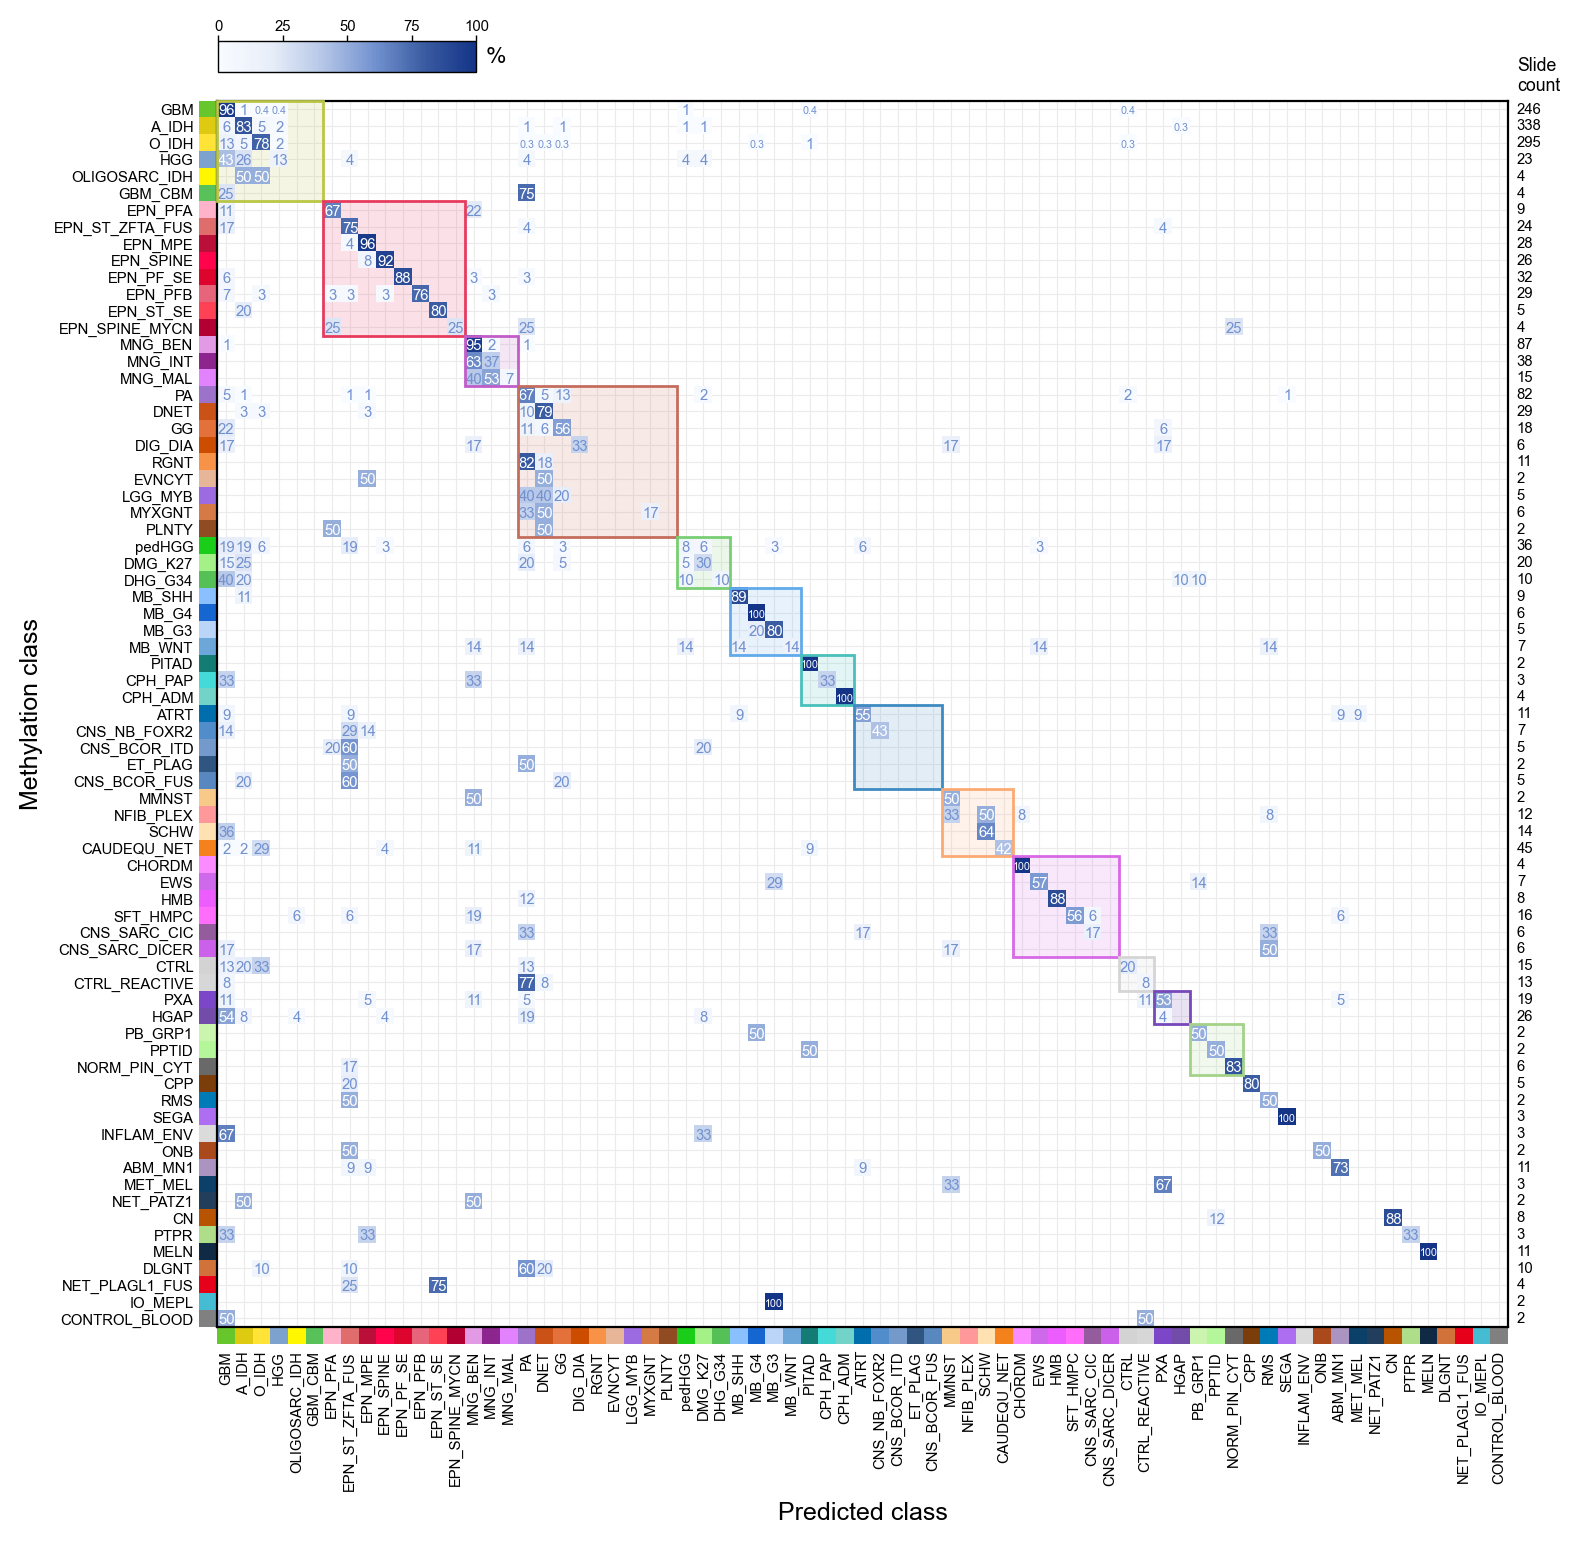

In [360]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix
import h5py

def get_dkfz_colormap(n_bins=100):
    """Create DKFZ colormap with white for NaN values."""
    colors = np.array([
        [248, 251, 255], 
        [232, 238, 249],
        [182, 199, 231.5], 
        [116, 147, 208], 
        [58, 92, 162], 
        [20, 52, 135]
    ])
    cmap = LinearSegmentedColormap.from_list('dkfz', colors / 255, N=n_bins)
    cmap.set_bad(color=(1, 1, 1, 0))
    return cmap


extra_info = ukhd_preds.extra_info
extra_info.loc[extra_info['Class'] == 'control tissue, blood', 'Abbr_class'] = "CONTROL_BLOOD"
labels = external_preds['labels']
preds = external_preds['pred1']


# Prepare data
ordered_labels = extra_info['label_class'].tolist()
tumor_name_ls = extra_info['Abbr_class']
color_ls = extra_info['color_code_class'].str.strip()
superfamily_colour = extra_info['color_code_sf'].str.strip()

# Create and filter confusion matrix
cm = confusion_matrix(labels, preds, labels=ordered_labels)
sample_counts_per_class = cm.sum(axis=1)
mask = sample_counts_per_class > 1

cm_unpooled = cm[mask][:, mask]
tumor_ls = tumor_name_ls[mask]
color_ls = color_ls[mask]
superfamily_colour = superfamily_colour[mask]

# Normalize confusion matrix
cm_normalized = cm_unpooled.copy() / cm_unpooled.sum(1, keepdims=True)
cm_normalized[cm_normalized == 0] = np.nan

# Create figure and plot heatmap
colormap = get_dkfz_colormap()
f_size = 5.35
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(cm_normalized, interpolation='nearest', aspect=0.95, cmap=colormap, zorder=3)

# Configure axes
ax.set_xticks(np.arange(len(tumor_ls)))
ax.set_yticks(np.arange(len(tumor_ls)))
ax.set_xticklabels(tumor_ls, rotation=90, fontsize=f_size, fontdict={'family': 'Arial'})
ax.set_yticklabels(tumor_ls, fontsize=f_size, fontdict={'family': 'Arial'})
ax.set_xlabel('Predicted class', fontsize=9, fontdict={'family': 'Arial'})
ax.set_ylabel('Methylation class', fontsize=9, fontdict={'family': 'Arial'})
ax.grid(which='minor', color='white', linestyle='-', linewidth=0.3)

# Add percentage labels to cells
for i in range(len(tumor_ls)):
    for j in range(len(tumor_ls)):
        value = cm_normalized[i, j] * 100
        if not np.isnan(value):
            color = 'w' if value > 40 else get_dkfz_colormap(100)(0.6)
            
            if value == 100:
                text_str = "%.0f" % value
                x_offset, size = 0, f_size - 1.5
            elif value > 0.5:
                text_str = "%.0f" % value
                x_offset, size = 0.01, f_size
            else:
                text_str = ("%.1f" % value).lstrip('1')
                x_offset, size = 0.01, f_size - 1.5
            
            ax.text(j + x_offset, i + 0.08, text_str, ha='center', va='center', 
                   color=color, fontsize=size, fontdict={'family': 'Arial'}, zorder=5)

# Add sample counts column
sample_counts = np.nansum(cm_unpooled, axis=1)
ax.text(cm_normalized.shape[1], -2.0, 'Slide\ncount', va='center', 
       fontsize=f_size + 1.0, fontdict={'family': 'Arial'}, ha='left')
for i, count in enumerate(sample_counts):
    ax.text(cm_normalized.shape[1], i, str(count), va='center', 
           fontsize=f_size, fontdict={'family': 'Arial'}, ha='left')

# Add class color patches (left and bottom)
patch_width = 1.0
patch_x = -1.5
for i, color in enumerate(color_ls):
    # Left side
    if isinstance(color, float):
        color = 'gray'
    rect = Rectangle((patch_x - 0.05, i - 0.5), patch_width, 1, 
                    linewidth=0, edgecolor='none', facecolor=color, clip_on=False)
    ax.add_patch(rect)
    # Bottom
    rect = Rectangle((i - 0.5, cm_normalized.shape[0] - patch_x - 1.95), 1, patch_width, 
                    linewidth=0, edgecolor='none', facecolor=color, clip_on=False)
    ax.add_patch(rect)

# Add superfamily rectangles
superfamily_groups = []
cur_idx = 0
cur_col = superfamily_colour[0]
for num, col in enumerate(superfamily_colour):
    if col != cur_col:
        superfamily_groups.append((cur_idx, num, cur_col))
        cur_idx = num
        cur_col = col
superfamily_groups.append((cur_idx, num + 1, cur_col))

for start, stop, col in superfamily_groups:
    size = stop - start
    if size > 1:
        rgba_col = to_rgba(col)[:3] + (0.15,)
        # Border
        rect = Rectangle((start - 0.5, start - 0.5), size, size, 
                        linewidth=1, edgecolor=col, facecolor='none', 
                        clip_on=False, zorder=10)
        ax.add_patch(rect)
        # Fill
        rect = Rectangle((start - 0.5, start - 0.5), size, size, 
                        linewidth=1, edgecolor='none', facecolor=rgba_col, clip_on=False)
        ax.add_patch(rect)

# Configure grid and styling
ax.tick_params(which='minor', bottom=False, left=False)
plt.grid(which='major', axis='both', linestyle='-', color=(0.92, 0.92, 0.92), 
        linewidth=0.4, zorder=-4)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_zorder(4)
ax.tick_params(axis='both', which='major', pad=5)

# Add colorbar
cbar_ax = inset_axes(ax, width="20%", height="2.5%", loc='upper left', 
                    bbox_to_anchor=(-0.01, 0.06, 1, 1), bbox_transform=ax.transAxes)
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.outline.set_linewidth(0.5)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=f_size, width=0.5, length=2)
cbar.ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
cbar.ax.set_xticklabels(['0', '25', '50', '75', '100'], fontdict={'family': 'Arial'})
cbar.ax.text(1.075, 0.5, '%', ha='center', va='center', 
            fontsize=f_size + 3, fontdict={'family': 'Arial'})
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.5)
cbar.ax.tick_params(axis='both', which='major', pad=0.7)

# Save and show
fig.tight_layout()
plt.show()

## Extended data figure 5: distribution of of tumor types in eBRAINS dataset


In [25]:
ebrains_prediction = Predictions(
    "../backup/predictions/avg_eBRAINS_preds.h5",
    label_file_path="../backup/labels/eBRAINS_labels.csv",
)
ebrains_preds = ebrains_prediction.predictions

ebrains_sf_color = pd.read_csv("ebrains_classes_color_codes.csv")
ebrains_sf_color["class_count"] = ebrains_sf_color["class"].map(
    ebrains_preds["class"].value_counts()
)
ebrains_sf_color["sf_count"] = ebrains_sf_color["superfamily"].map(
    ebrains_prediction.extra_info.set_index("Abbr_SF")["superfamily_order"].to_dict()
)
ebrains_sf_color.sort_values(
    by=["sf_count", "class_count"], ascending=[False, False], inplace=True
)
ebrains_sf_color["freq_class"] = (
    ebrains_sf_color["class_count"] / ebrains_sf_color["class_count"].sum()
)

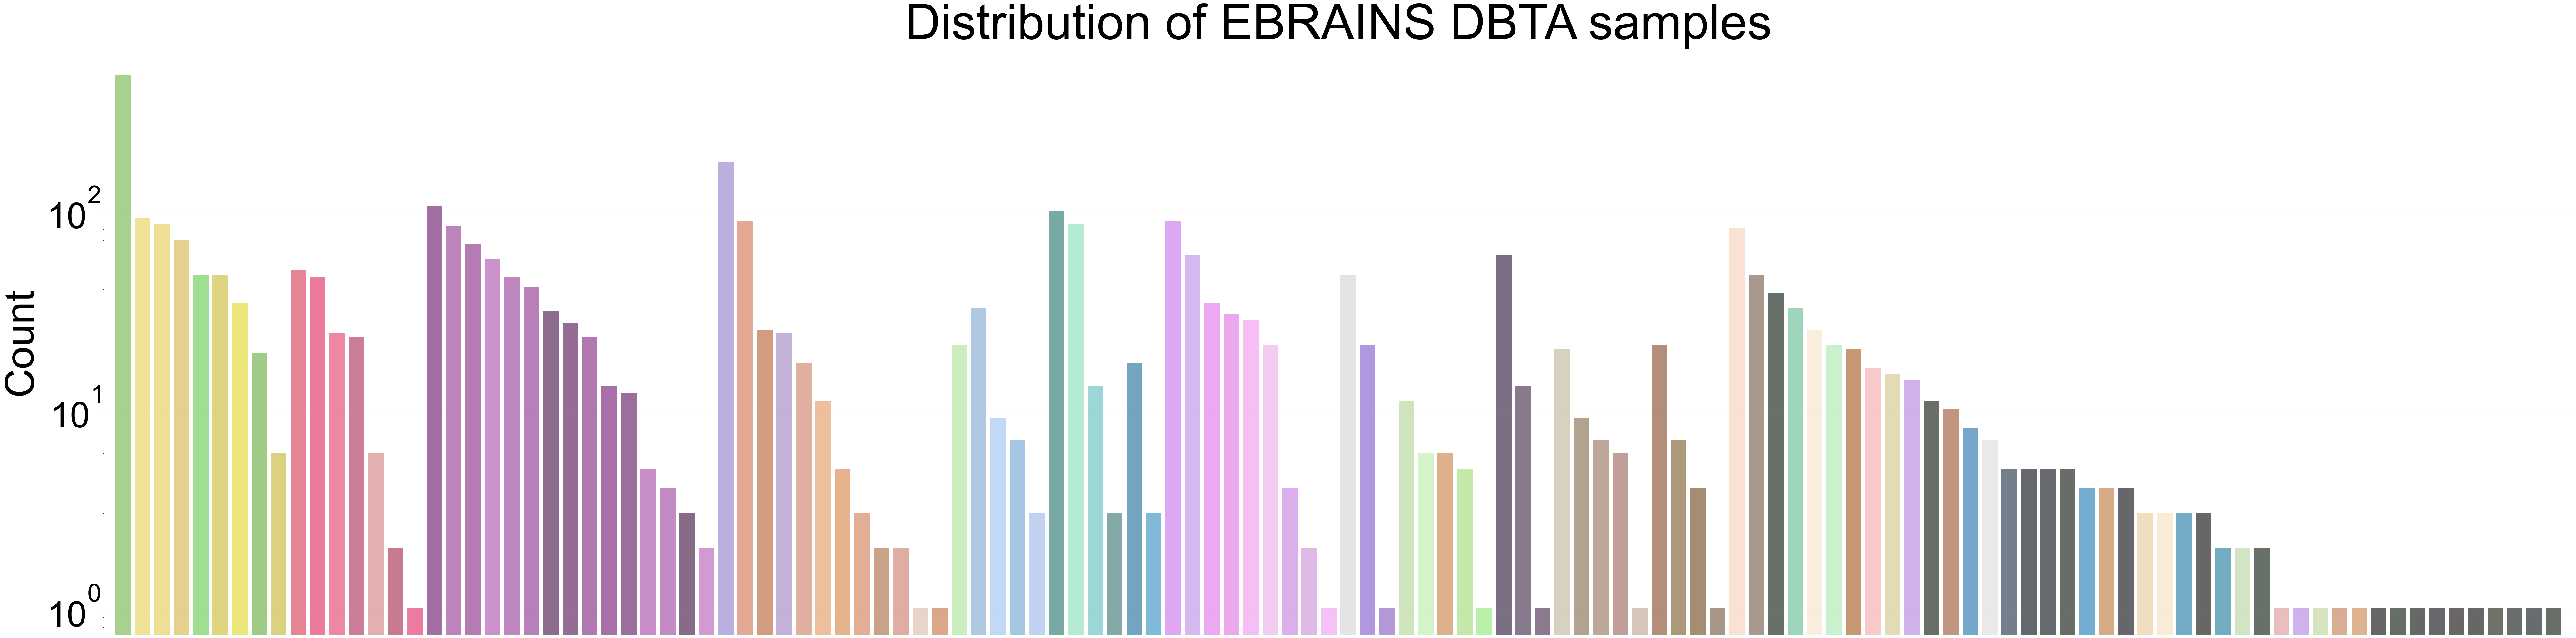

In [28]:
fig, ax = plt.subplots(figsize=(80, 20))
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'
custom_palette = ebrains_sf_color.set_index('class')['color_code'].to_dict()

sns.barplot(x='class', y='class_count', data=ebrains_sf_color, hue='class', palette=custom_palette, label='eBRAINS', legend=False, alpha=0.6)  # Distribution of external validation dataset
plt.title('Distribution of EBRAINS DBTA samples', fontsize=110, pad=15)

plt.ylabel('Count', fontsize=90, labelpad=15)
plt.xlabel('')

plt.xticks([])

plt.xlim(-1, 126)
plt.yscale('log')
plt.xticks(fontsize=32, rotation=45, ha='right')   
ax.xaxis.set_tick_params(pad=20)
plt.tick_params(axis='y', labelsize=80)
plt.grid(True, linestyle='--', alpha=0.5)
plt.box(False)
plt.tight_layout()
# plt.show()
plt.savefig('/Users/jindarui/Desktop/Hetairos_project/投稿/submission/editorial_checklist_v3/figures/edf5/ebrains_distribution.pdf')

y_max_bin
0.0-0.1     50
0.1-0.2    352
0.2-0.3    402
0.3-0.4    391
0.4-0.5    344
0.5-0.6    337
0.6-0.7    347
0.7-0.8    381
0.8-0.9    380
0.9-1.0    126
Name: count, dtype: int64


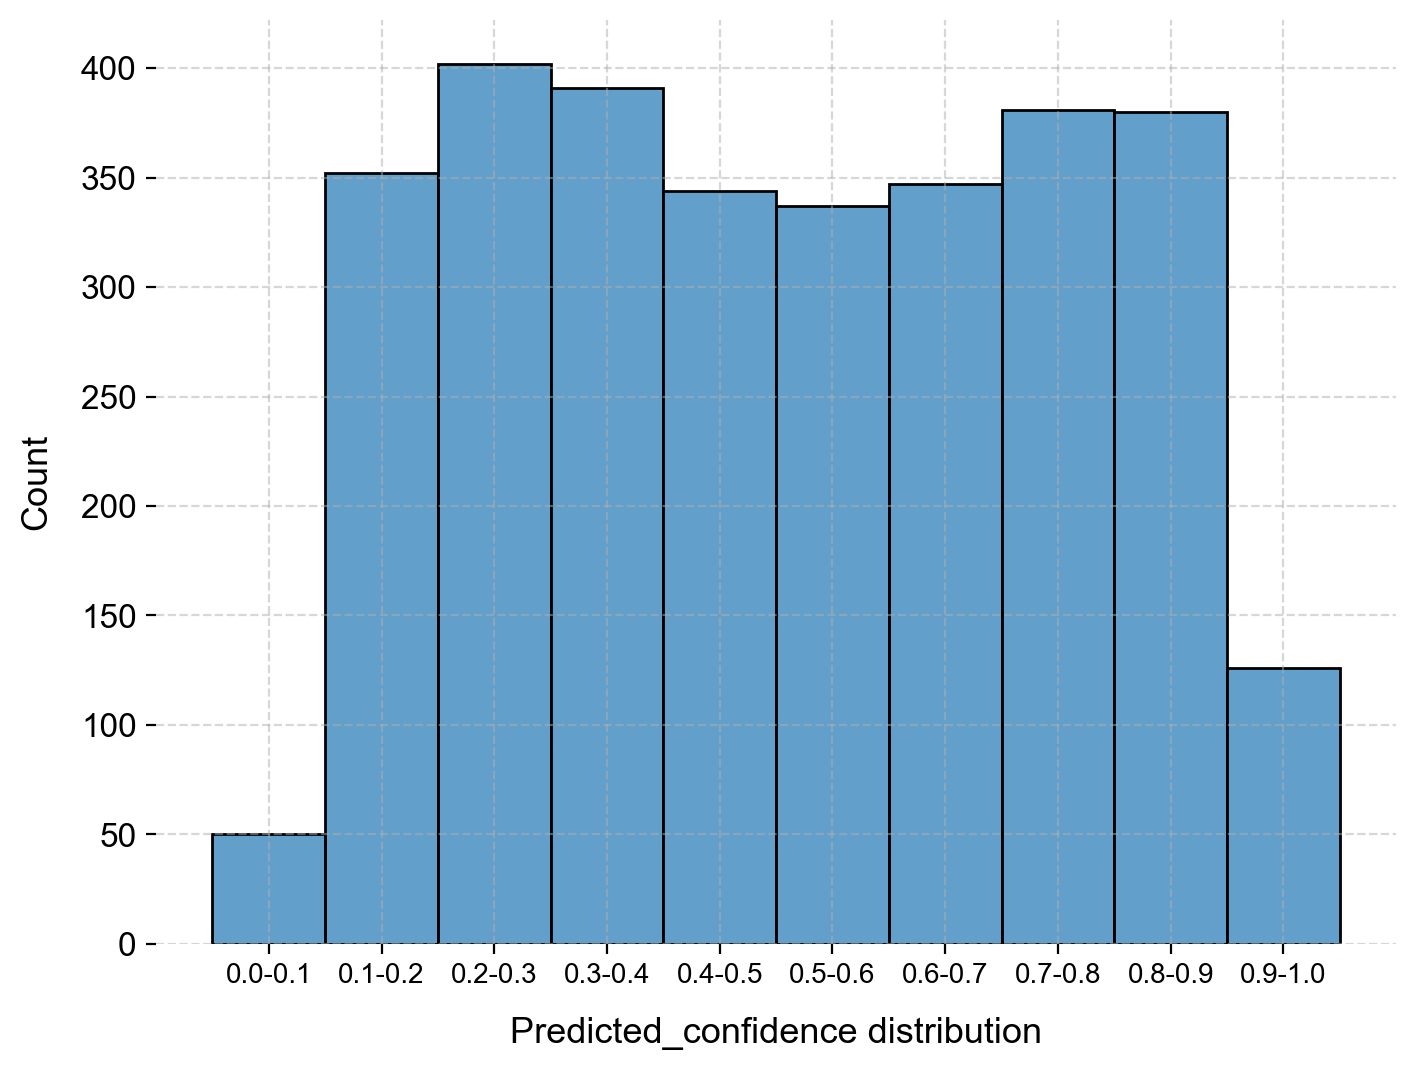

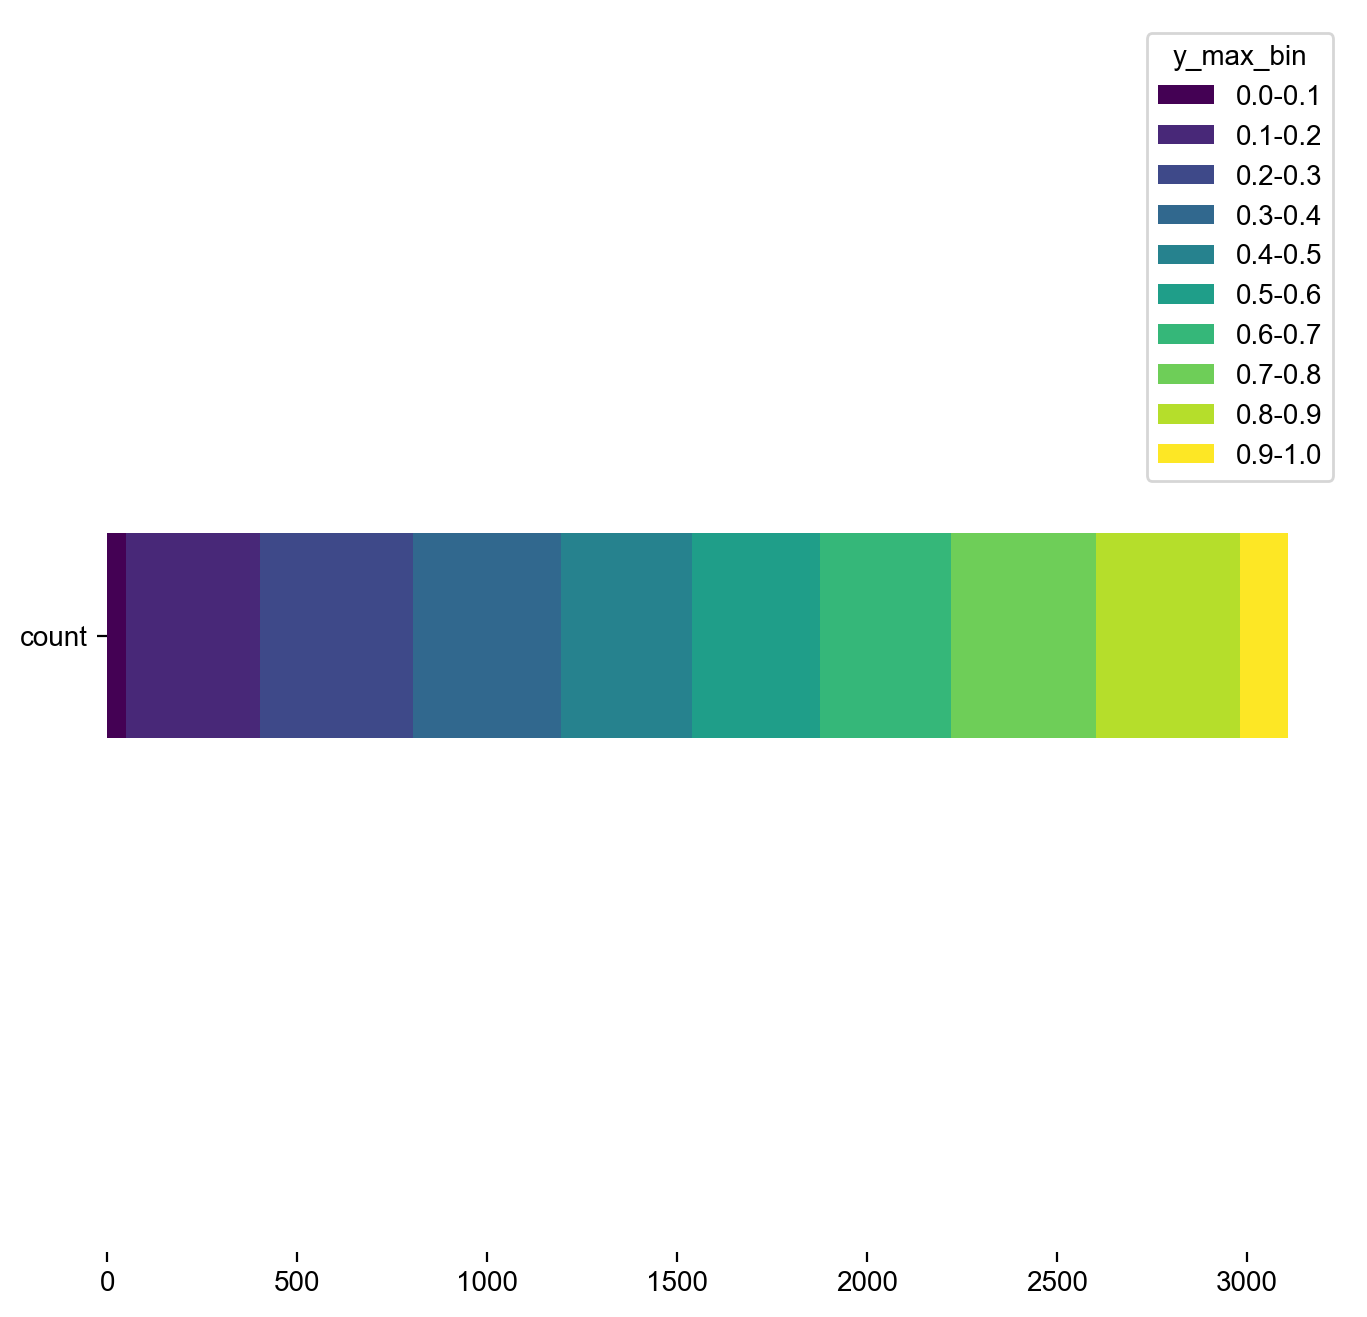

In [326]:
ebrains_confidence = (
    ebrains_prediction.plot_confidence_distribution()
)  # get confidence distribution (pd.series)
conf_df = pd.DataFrame(ebrains_confidence).T
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(conf_df.columns)))
conf_df.plot(kind="barh", stacked=True, width=0.1, color=colors, figsize=(8, 8))
plt.box(False)
plt.show()

In [327]:
ebrains_preds["pred_tumor"] = ebrains_preds.pred1.map(
    ebrains_prediction.int2str_mapping
)
ebrains_preds["sf_count"] = ebrains_preds["class"].map(
    ebrains_sf_color.set_index("class")["sf_count"]
)
ebrains_preds["class_count"] = ebrains_preds["class"].map(
    ebrains_sf_color.set_index("class")["class_count"]
)
ebrains_preds["color_code"] = ebrains_preds["class"].map(
    ebrains_sf_color.set_index("class")["color_code"]
)
ebrains_preds["pred_color_code"] = ebrains_preds["pred_tumor"].map(
    ebrains_prediction.extra_info.set_index("Class")["color_code_class"]
)
ebrains_preds["pred_abbr"] = ebrains_preds["pred_tumor"].map(
    ebrains_prediction.extra_info.set_index("Class")["Abbr_class"]
)
ebrains_preds.sort_values(
    ["sf_count", "class_count"], ascending=[False, False], inplace=True
)

In [328]:
def sankey_inputs_convert_ebrains(pred_df, output_path, color_ref):
    preds = pred_df['pred_abbr'].unique()
    sources = pred_df['class'].unique()
    with open(output_path, 'a') as f:
        for item in preds:
            color_code = pred_df[pred_df['pred_abbr'] == item]['pred_color_code'].values[0]
            f.write(f":{item} {color_code[:7]}\n")
        for item in sources:
            color_code = pred_df[pred_df['class']==item]['color_code'].values[0]
            f.write(f":{item} {color_code[:7]}\n")
        
        for pred in preds:
            sub_df = pred_df[pred_df['pred_abbr'] == pred]
            count = sub_df['class'].value_counts()
            for key, value in count.items():
                # 写入txt文本，格式为 true [count] preds
                f.write(f"{key} [{value}] {pred}\n")

In [329]:
high_confidence_ebrains = ebrains_preds[ebrains_preds.top1_conf > 0.5]
low_confidence_ebrains = ebrains_preds[ebrains_preds.top1_conf <= 0.5]
sankey_inputs_convert_ebrains(
    high_confidence_ebrains, "sankey_plot_data_ebrains_low_conf.txt", ebrains_sf_color
)
sankey_inputs_convert_ebrains(
    low_confidence_ebrains, "sankey_plot_data_ebrains_low_conf.txt", ebrains_sf_color
)

## Figure 5b: Accuracy comparison between Hetairos and human pathologists in different confidence intervals

In [5]:
ref = pd.read_csv(str(HM_DIR / "hm_labels.csv"))

def human_preds_analysis(preds_path: str, ref: pd.DataFrame = ref):
    preds = pd.read_excel(preds_path, sheet_name="Sheet1")
    preds = pd.merge(preds, ref, on="uuid", how="left")
    preds.drop_duplicates(subset=["uuid"], inplace=True)
    preds.replace({'class': {np.nan: 'Liponeurocytoma'}}, inplace=True)
    top1_acc = np.mean(preds["class"] == preds["class 1"])
    top3_acc = np.mean(
        preds.apply(
            lambda x: x["class"] in [x["class 1"], x["class 2"], x["class 3"]], axis=1
        )
    )
    print(f"Top1 accuracy: {top1_acc*100:.2f}%")
    print(f"Top3 accuracy: {top3_acc*100:.2f}%\n")

    preds["top3_match"] = preds.apply(
        lambda x: x["class"] in [x["class 1"], x["class 2"], x["class 3"]], axis=1
    )
    preds["top1_match"] = preds["class"] == preds["class 1"]
    cls_wise_top1 = (
        preds.groupby("class")["top1_match"]
        .mean()
        .reset_index(name="class_wise_top1_acc")
    )
    cls_wise_top3 = (
        preds.groupby("class")["top3_match"]
        .mean()
        .reset_index(name="class_wise_top3_acc")
    )
    out_preds = preds[
        ["uuid", "class", "class 1", "class 2", "class 3", "top1_match", "top3_match"]
    ].copy()
    out_preds.rename(
        columns={
            "uuid": "slide_ID",
            "class 1": "pred1",
            "class 2": "pred2",
            "class 3": "pred3",
        },
        inplace=True,
    )
    return [cls_wise_top1, cls_wise_top3], out_preds

In [6]:
preds_root = str(HM_DIR / "predictions/human")

cls_wise_results_1, predictions1 = human_preds_analysis(
    os.path.join(preds_root, "1-Evaluator1.xlsx")
)
cls_wise_results_2, predictions2 = human_preds_analysis(
    os.path.join(preds_root, "2-Evaluator2.xlsx")
)
cls_wise_results_3, predictions3 = human_preds_analysis(
    os.path.join(preds_root, "3-Evaluator3.xlsx")
)
cls_wise_results_4, predictions4 = human_preds_analysis(
    os.path.join(preds_root, "4-Evaluator4.xlsx")
)
cls_wise_results_5, predictions5 = human_preds_analysis(
    os.path.join(preds_root, "5-Evaluator5.xlsx")
)

inte_cls_wise_results = pd.DataFrame({"class": cls_wise_results_1[0]["class"]})
inte_cls_wise_results["acc"] = (
    cls_wise_results_1[0]["class_wise_top1_acc"]
    + cls_wise_results_2[0]["class_wise_top1_acc"]
    + cls_wise_results_3[0]["class_wise_top1_acc"]
    + cls_wise_results_4[0]["class_wise_top1_acc"]
) / 4

Top1 accuracy: 33.81%
Top3 accuracy: 69.05%

Top1 accuracy: 28.57%
Top3 accuracy: 44.76%

Top1 accuracy: 32.38%
Top3 accuracy: 51.43%

Top1 accuracy: 18.10%
Top3 accuracy: 30.48%

Top1 accuracy: 34.76%
Top3 accuracy: 53.33%



/Users/jindarui/micromamba/envs/currypop/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/jindarui/micromamba/envs/currypop/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/jindarui/micromamba/envs/currypop/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
/Users/jindarui/micromamba/envs/currypop/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [7]:
model_preds = Predictions(
    pred_file_path=str(HM_DIR / "predictions/model"),
    label_file_path=str(HM_DIR / "hm_labels.csv"),
)
preds_model = model_preds.predictions

In [8]:
bins = [i / 10 for i in range(11)]
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]
preds_model["y_max_bin"] = pd.cut(
    preds_model["top1_conf"], bins=bins, labels=labels, include_lowest=True
)
model_acc = (
    preds_model.groupby("y_max_bin", observed=False)
    .apply(lambda x: np.mean(x["labels"] == x["pred1"]), include_groups=False)
    .reset_index(name="acc")
)
model_conf = (
    preds_model.groupby("y_max_bin", observed=False)["top1_conf"]
    .mean()
    .reset_index(name="mean_conf")
)
model_conf_acc = pd.merge(model_conf, model_acc, on="y_max_bin", how="left")

In [9]:
predictions1["y_max_bin"] = predictions1["slide_ID"].map(
    preds_model.set_index("slide_ID")["y_max_bin"].to_dict()
)
predictions2["y_max_bin"] = predictions2["slide_ID"].map(
    preds_model.set_index("slide_ID")["y_max_bin"].to_dict()
)
predictions3["y_max_bin"] = predictions3["slide_ID"].map(
    preds_model.set_index("slide_ID")["y_max_bin"].to_dict()
)
predictions4["y_max_bin"] = predictions4["slide_ID"].map(
    preds_model.set_index("slide_ID")["y_max_bin"].to_dict()
)

interval_acc_1 = (
    predictions1.groupby("y_max_bin")
    .apply(lambda x: np.mean(x["class"] == x["pred1"]), include_groups=False)
    .reset_index(name="acc")
)
interval_acc_2 = (
    predictions2.groupby("y_max_bin")
    .apply(lambda x: np.mean(x["class"] == x["pred1"]), include_groups=False)
    .reset_index(name="acc")
)
interval_acc_3 = (
    predictions3.groupby("y_max_bin")
    .apply(lambda x: np.mean(x["class"] == x["pred1"]), include_groups=False)
    .reset_index(name="acc")
)
interval_acc_4 = (
    predictions4.groupby("y_max_bin")
    .apply(lambda x: np.mean(x["class"] == x["pred1"]), include_groups=False)
    .reset_index(name="acc")
)

mean_human_acc = pd.DataFrame({"y_max_bin": interval_acc_1["y_max_bin"]})
mean_human_acc["acc"] = (
    interval_acc_1["acc"]
    + interval_acc_2["acc"]
    + interval_acc_3["acc"]
    + interval_acc_4["acc"]
) / 4

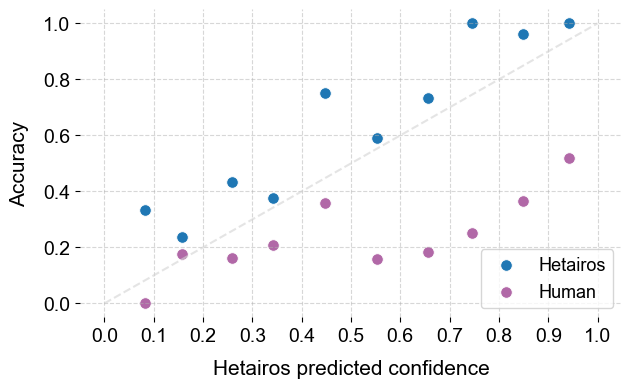

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'
sns.scatterplot(data=model_conf_acc, x='mean_conf', y='acc', s=70, label='Hetairos')
sns.scatterplot(x=model_conf_acc['mean_conf'], y=mean_human_acc['acc'], label='Human', s=70, color='#B168A7')
plt.xlabel('Hetairos predicted confidence', fontsize=15, labelpad=10)
plt.ylabel('Accuracy', fontsize=15, labelpad=10)
plt.xticks(np.arange(0,1.1,0.1), fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.box(False)
plt.legend(title='', fontsize=13, title_fontsize=13, loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--', color='lightgray', alpha=0.6)
# plt.show()
plt.savefig('/Users/jindarui/Desktop/Hetairos_project/投稿/submission/editorial_checklist_v3/figures/figure_5/Hetairos_human_comparison.pdf',
            bbox_inches='tight')

## Figure 5c: Delta accuracy vs training sample size in human vs machine validation


In [17]:
model_preds = Predictions(
    pred_file_path=str(HM_DIR / "predictions/model"),
    label_file_path=str(HM_DIR / "hm_labels.csv"),
)
preds_model = model_preds.predictions

model_cls_wise_results = model_preds.get_cls_wise_results()
model_human_cls_wise_results = pd.merge(
    inte_cls_wise_results,
    model_cls_wise_results,
    on="class",
    suffixes=("_human", "_model"),
)
model_human_cls_wise_results.rename(
    columns={"acc": "acc_human", "accuracy": "acc_model"}, inplace=True
)

model_human_cls_wise_results["delta_acc"] = (
    model_human_cls_wise_results["acc_model"]
    - model_human_cls_wise_results["acc_human"]
)

with open("../backup/train_val_split.yaml", "r") as fid:  # read data split file
    train_id = yaml.safe_load(fid)["train"]

label_file = ukhd_preds.label_file
label_file = label_file[label_file["slide_ID"].isin(train_id)]

training_count = (
    label_file.groupby("class")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="training_count")
)  # training sample size for each tumor type

model_human_cls_wise_results["training_count"] = model_human_cls_wise_results[
    "class"
].map(training_count.set_index("class")["training_count"].to_dict())

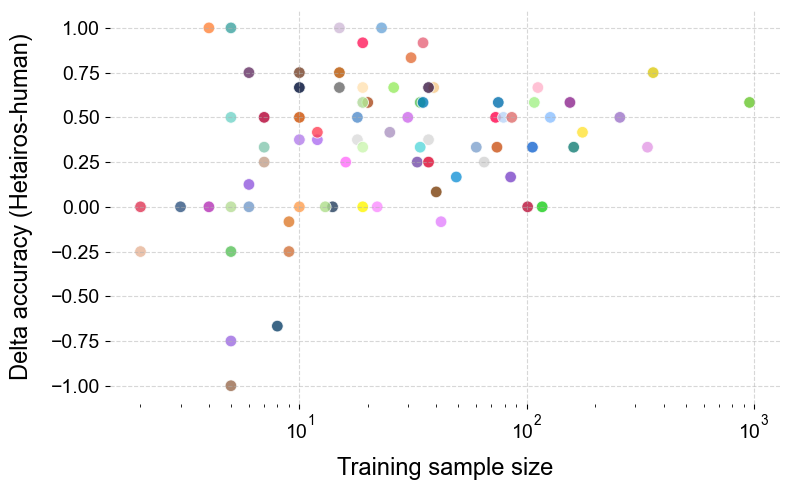

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.rcParams["font.family"] = "Arial"
mpl.rcParams['pdf.fonttype'] = 42
color_mapping = ukhd_preds.extra_info.set_index("Abbr_class")[
    "color_code_class"
].to_dict()
sns.scatterplot(
    data=model_human_cls_wise_results,
    x="training_count",
    y="delta_acc",
    hue="class",
    palette=ukhd_preds.get_color_mapping(),
    s=70,
    alpha=0.8,
    legend=False,
)
plt.xlabel("Training sample size", fontsize=17, labelpad=10)
plt.ylabel("Delta accuracy (Hetairos-human)", fontsize=17, labelpad=13)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xscale("log")
plt.grid(True, linestyle="--", alpha=0.5)
plt.box(False)
# plt.show()
plt.tight_layout()
plt.savefig('/Users/jindarui/Desktop/Hetairos_project/投稿/submission/editorial_checklist_v3/figures/figure_5/sample_size_delta_acc.pdf')

## Figure 6c Low methylation score samples

In [338]:
with h5py.File(str(PREDICTIONS_DIR / "avg_preds_low_mc.h5")) as fid:
    mnp_ids = fid["slide_id"][:]
    mnp_probs = fid["probs"][:]
    mnp_labels = fid["labels"][:]

mnp_df = pd.DataFrame(
    {
        "slide_id": mnp_ids,
        "probs": list(mnp_probs),
        "preds": np.argmax(mnp_probs, axis=1),
        "top2_pred": np.argsort(mnp_probs, axis=1)[:, -2],
        "top3_pred": np.argsort(mnp_probs, axis=1)[:, -3],
        "labels": mnp_labels,
    }
)
mnp_df["family"] = mnp_df["labels"].map(ukhd_preds.int2str_mapping)
mnp_df["top1_conf"] = np.max(mnp_probs, axis=1)
mnp_df = mnp_df.dropna(subset=["labels"]).reset_index(drop=True)
mnp_df["top3_match"] = mnp_df.apply(
    lambda x: x["labels"] in [x["preds"], x["top2_pred"], x["top3_pred"]], axis=1
)
bins = [i / 10 for i in range(11)]
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]
mnp_df["y_max_bin"] = pd.cut(
    mnp_df["top1_conf"], bins=bins, labels=labels, include_lowest=True
)

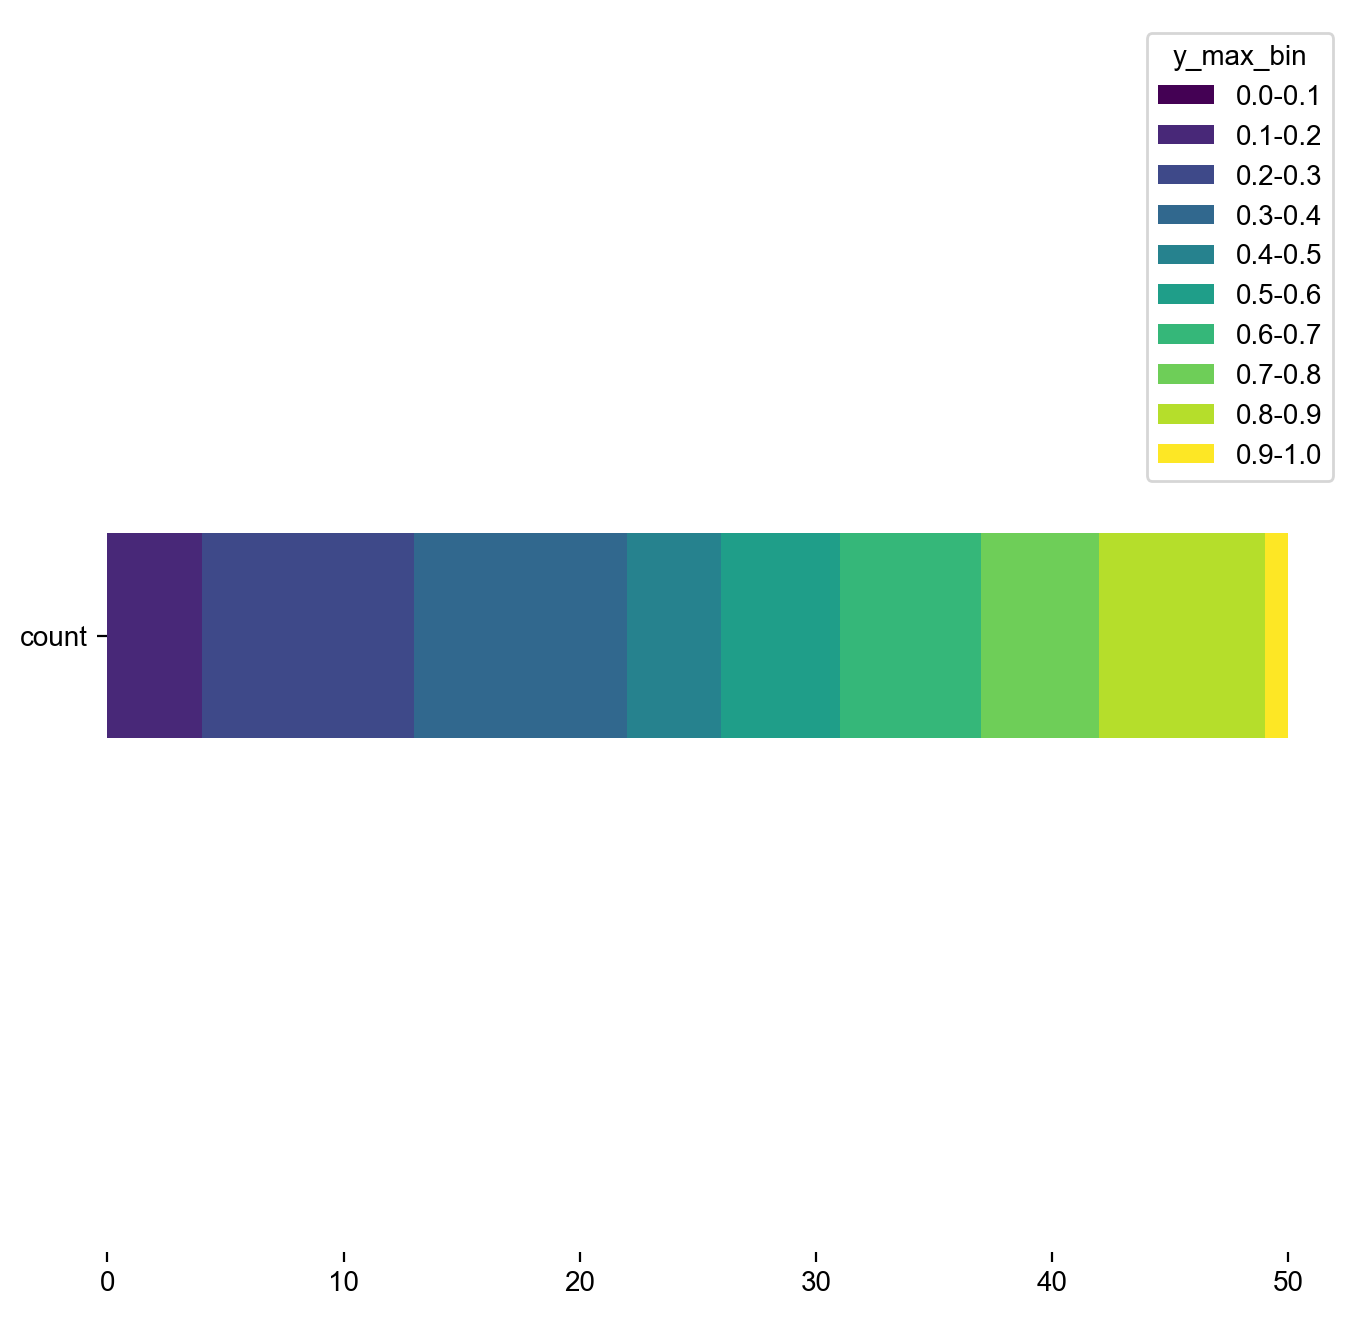

In [339]:
mnp_conf_count = mnp_df.value_counts("y_max_bin").sort_index()
mnp_conf_count = pd.DataFrame(mnp_conf_count).T

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(mnp_conf_count.columns)))
mnp_conf_count.plot(kind="barh", stacked=True, width=0.1, color=colors, figsize=(8, 8))
plt.box(False)
plt.show()

In [340]:
def sankey_inputs_convert(pred_df, output_path, color_ref):
    labels = pred_df['true_abbr'].unique()
    preds = pred_df['pred_abbr'].unique()

    with open(output_path, 'a') as f:
        for item in preds:
            color_code = color_ref[item]
            f.write(f":{item}_pred {color_code[:7]}\n")
        for item in labels:
            color_code = color_ref[item]
            f.write(f":{item} {color_code[:7]}\n")
            f.write(f":{item}_pred {color_code[:7]}\n")
            sub_df = pred_df[pred_df['true_abbr'] == item]
            count = sub_df['pred_abbr'].value_counts()
            for key, value in count.items():
                f.write(f"{item} [{value}] {key}_pred\n")   

mnp_df["true_abbr"] = mnp_df["family"].map(
    ukhd_preds.extra_info.set_index("Class")["Abbr_class"].to_dict()
)
mnp_df["pred_abbr"] = (
    mnp_df["preds"]
    .map(ukhd_preds.int2str_mapping)
    .map(ukhd_preds.extra_info.set_index("Class")["Abbr_class"].to_dict())
)
high_confidence = mnp_df[mnp_df.top1_conf > 0.5]
low_confidence = mnp_df[mnp_df.top1_conf <= 0.5]

In [341]:
color_mapping = ukhd_preds.extra_info.set_index("Abbr_class")[
    "color_code_class"
].to_dict()
sankey_inputs_convert(
    high_confidence, "sankey_plot_data_mnp_high_conf.txt", color_mapping
)

In [342]:
color_mapping = ukhd_preds.extra_info.set_index("Abbr_class")[
    "color_code_class"
].to_dict()
sankey_inputs_convert(
    low_confidence, "sankey_plot_data_mnp_low_conf.txt", color_mapping
)

## Figure 6d Stereotatic biopsy examples


In [343]:
with h5py.File(str(PREDICTIONS_DIR / "avg_preds_STX_annot.h5")) as fid:
    stx_ids = fid["slide_id"][:]
    stx_probs = fid["probs"][:]
    stx_labels = fid["labels"][:]
    stx_family = fid["family"][:]

stx_family = [item.decode("utf-8") for item in stx_family]
stx_df = pd.DataFrame(
    {
        "slide_id": stx_ids,
        "probs": list(stx_probs),
        "preds": np.argmax(stx_probs, axis=1),
        "top2_pred": np.argsort(stx_probs, axis=1)[:, -2],
        "top3_pred": np.argsort(stx_probs, axis=1)[:, -3],
        "labels": stx_labels,
        "family": stx_family,
    }
)
stx_df["top1_conf"] = np.max(stx_probs, axis=1)
stx_df = stx_df.dropna(subset=["labels"]).reset_index(drop=True)
stx_df["top3_match"] = stx_df.apply(
    lambda x: x["labels"] in [x["preds"], x["top2_pred"], x["top3_pred"]], axis=1
)

In [344]:
bins = [i / 10 for i in range(11)]
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)]
stx_df["y_max_bin"] = pd.cut(
    stx_df["top1_conf"], bins=bins, labels=labels, include_lowest=True
)

stx_conf_count = stx_df.value_counts("y_max_bin").sort_index()
stx_conf_count = pd.DataFrame(stx_conf_count).T

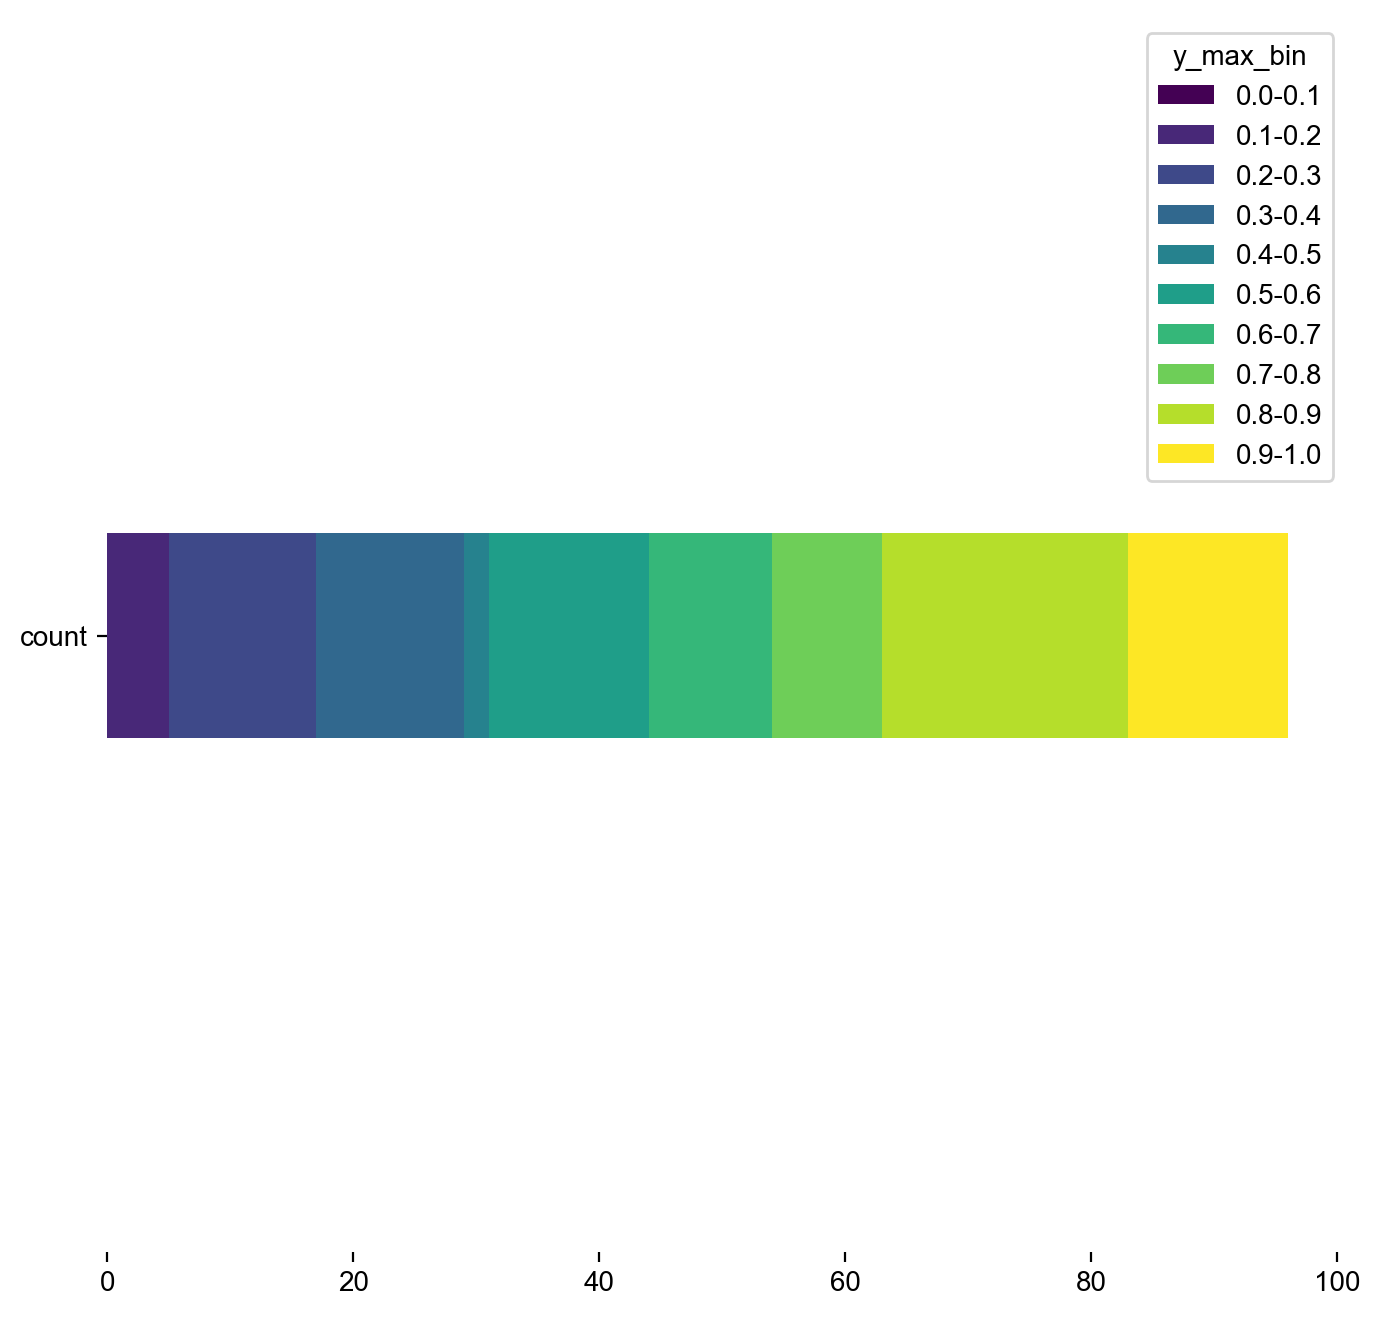

In [345]:
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(stx_conf_count.columns)))
stx_conf_count.plot(kind="barh", stacked=True, width=0.1, color=colors, figsize=(8, 8))
plt.box(False)
plt.show()

In [346]:
def sankey_inputs_convert(pred_df, output_path, color_ref):
    labels = pred_df['true_abbr'].unique()
    with open(output_path, 'a') as f:
        for item in labels:
            color_code = color_ref[item]
            f.write(f":{item} {color_code[:7]}\n")
            f.write(f":{item}_pred {color_code[:7]}\n")
            sub_df = pred_df[pred_df['true_abbr'] == item]
            count = sub_df['pred_abbr'].value_counts()
            for key, value in count.items():
                # format: true [count] preds
                f.write(f"{item} [{value}] {key}_pred\n")

In [347]:
high_confidence = stx_df[stx_df.top1_conf > 0.5].copy()
high_confidence["true_abbr"] = high_confidence["family"].map(
    ukhd_preds.extra_info.set_index("Class")["Abbr_class"].to_dict()
)
high_confidence["pred_abbr"] = (
    high_confidence["preds"]
    .map(ukhd_preds.int2str_mapping)
    .map(ukhd_preds.extra_info.set_index("Class")["Abbr_class"].to_dict())
)

color_mapping = ukhd_preds.extra_info.set_index("Abbr_class")[
    "color_code_class"
].to_dict()
sankey_inputs_convert(
    high_confidence, "sankey_plot_data_stx_high_conf.txt", color_mapping
)

In [348]:
low_confidence = stx_df[stx_df.top1_conf <= 0.5].copy()
low_confidence["true_abbr"] = low_confidence["family"].map(
    ukhd_preds.extra_info.set_index("Class")["Abbr_class"].to_dict()
)
low_confidence["pred_abbr"] = (
    low_confidence["preds"]
    .map(ukhd_preds.int2str_mapping)
    .map(ukhd_preds.extra_info.set_index("Class")["Abbr_class"].to_dict())
)
sankey_inputs_convert(
    low_confidence, "sankey_plot_data_stx_low_conf.txt", color_mapping
)

# Figure 8 Kaplan-Meier analysis using the MNP cohort


In [349]:
with open("Tumor_label_mapping.yaml", "r") as fid:
    mapping = yaml.safe_load(fid)["mapping"]
reverse_mapping = {v: k for k, v in mapping.items()}

ref_info_mnp = pd.read_csv("./labels/MNP_OS.csv")
ref_info_mnp["labels"] = ref_info_mnp["possible further consolidation"].map(mapping)

with h5py.File("./predictions/avg_preds_mnp_os.h5", "r") as fid:
    uuid = fid["slide_id"][:].astype(str)
    mean_prob = fid["probs"][:]
    labels = fid["labels"][:]

In [350]:
preds_df = pd.DataFrame(
    {
        "uuid": uuid,
        "preds": np.argmax(mean_prob, axis=1),
        "top1_conf": np.max(mean_prob, axis=1),
    }
)
preds_df = pd.merge(
    preds_df, ref_info_mnp[["uuid", "labels", "event_code"]], how="left", on="uuid"
)
preds_df = preds_df[~preds_df["labels"].isna()]
preds_df["os"] = preds_df["uuid"].map(
    ref_info_mnp.set_index("uuid")["overall survival"].to_dict()
)
preds_df["patient_ID"] = preds_df["uuid"].map(
    ref_info_mnp.set_index("uuid")["patient_ID"].to_dict()
)
preds_df["who_type"] = preds_df["uuid"].map(
    ref_info_mnp.set_index("uuid")["who_type"].to_dict()
)

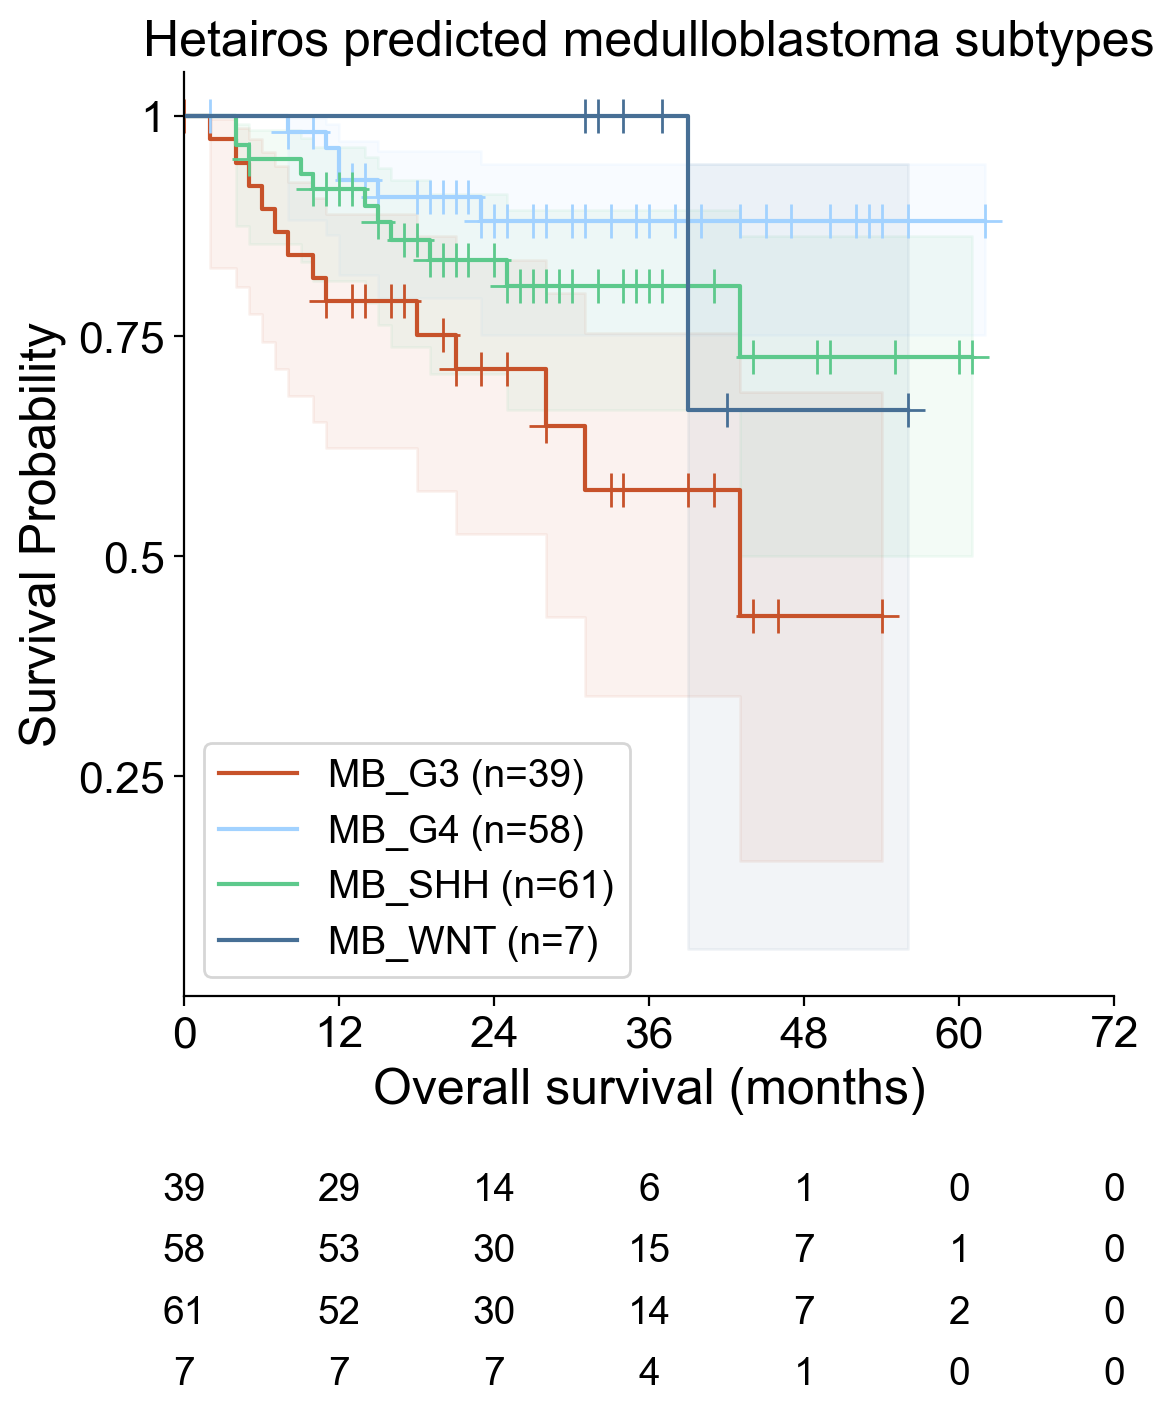

In [351]:
# survival analysis for the medulloblastoma group
mb_subset = preds_df[(preds_df['preds'].isin([12, 18, 7, 42])) & (~preds_df['os'].isna())]  # & (preds_df['who_type']=='medulloblastoma')
grp_mb3 = mb_subset[mb_subset['preds']==18]
grp_mb4 = mb_subset[mb_subset['preds']==12]
grp_mbshh = mb_subset[mb_subset['preds']==7]
grp_mbwnt = mb_subset[mb_subset['preds']==42]
s_size = [len(grp_mb3), len(grp_mb4), len(grp_mbshh), len(grp_mbwnt)]

from lifelines import KaplanMeierFitter
from matplotlib.ticker import FuncFormatter, MultipleLocator
from lifelines.plotting import add_at_risk_counts
%config InlineBackend.figure_format='retina'

colors = ['#c7522a', '#a2d2ff', '#5DC98C', '#476f95']
kmf = KaplanMeierFitter()
lb = ['MB_G3', 'MB_G4', 'MB_SHH', 'MB_WNT']
ax = plt.gca()
interval = 12
at_risk_data = []
for idx, grp in enumerate([grp_mb3, grp_mb4, grp_mbshh, grp_mbwnt]):
    kmf.fit(grp['os'], event_observed=grp['event_code'], label=f"{lb[idx]} (n={s_size[idx]})")
    kmf.plot_survival_function(show_censors=True, figsize=(6, 6), color=colors[idx], ci_alpha=0.07)
    times = kmf.event_table.index
    at_risk = kmf.event_table['at_risk']
    selected_times = np.arange(0, 73, interval)
    selected_at_risk = [at_risk.iloc[times.searchsorted(t)] if t <= times.max() else 0 for t in selected_times]
    at_risk_data.append((lb[idx], selected_times, selected_at_risk))

for idx, (label, times, at_risk) in enumerate(at_risk_data):
    for t, n in zip(times, at_risk):
        ax.text(t, -0.2 - idx * 0.07, f"{int(n)}", 
                ha='center', va='top', fontsize=14, color='k')
        
plt.rcParams['font.family'] = 'Arial'
mpl.rcParams['pdf.fonttype'] = 42
plt.title('Hetairos predicted medulloblastoma subtypes', fontsize=18)
plt.xlabel('Overall survival (months)', fontsize=18)
plt.ylabel('Survival Probability', fontsize=18)
plt.legend(title='', loc='lower left', fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 1.05)
plt.xlim(0, 72)
ax.set_yticks([1, 0.75, 0.5, 0.25])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}' if y.is_integer() else f'{y}'))
ax.xaxis.set_major_locator(MultipleLocator(12))
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False) 
plt.show()

In [352]:
from matplotlib.colors import LinearSegmentedColormap

def get_dkfz_colormap(n_bins=100):
    colors = np.array(
        [
            [248, 251, 255],
            [215, 225, 243.25],
            [182, 199, 231.5],
            [116, 147, 208],
            [58, 92, 162],
            [20, 52, 135],
        ]
    )
    cmap = LinearSegmentedColormap.from_list("dkfz", colors / 255, N=n_bins)
    return cmap


colormap = get_dkfz_colormap()
colormap.set_bad(color=np.array([248, 251, 255]) / 255)

/var/folders/fj/2mkb2fwd27x3yb8l_fcvb6c80000gs/T/ipykernel_4489/2821586171.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mb_subset["labels"] = mb_subset["labels"].apply(
/var/folders/fj/2mkb2fwd27x3yb8l_fcvb6c80000gs/T/ipykernel_4489/2821586171.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mb_subset["preds"] = mb_subset["preds"].apply(


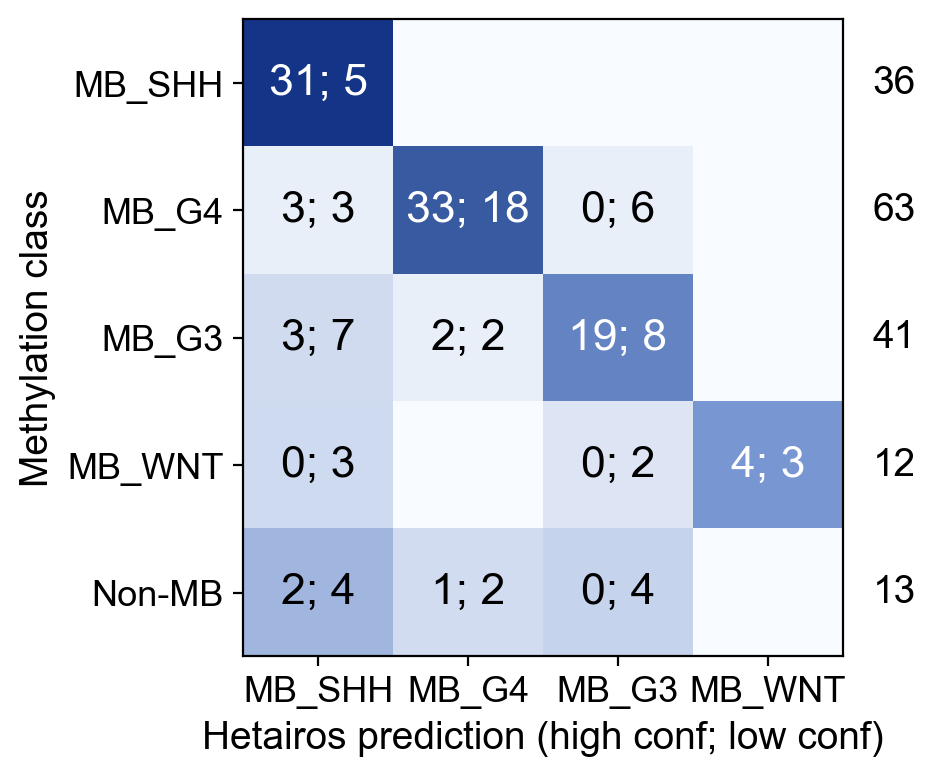

In [353]:
fig, ax = plt.subplots(figsize=(10, 4))
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mb_subset["labels"] = mb_subset["labels"].apply(
    lambda x: x if x in [12, 18, 7, 42] else 108
)
mb_subset["preds"] = mb_subset["preds"].apply(
    lambda x: x if x in [12, 18, 7, 42] else 108
)

mb_subset_high_conf = mb_subset[mb_subset['top1_conf'] > 0.5]
mb_subset_low_conf = mb_subset[mb_subset['top1_conf'] <= 0.5]

cm = confusion_matrix(
    mb_subset["labels"].values,
    mb_subset["preds"].values,
    labels=[7, 12, 18, 42] + [108],
)
cm = cm[:, :4]

cm_high_conf = confusion_matrix(
    mb_subset_high_conf["labels"].values,
    mb_subset_high_conf["preds"].values,
    labels=[7, 12, 18, 42] + [108],
)
cm_high_conf = cm_high_conf[:, :4]

cm_low_conf = confusion_matrix(
    mb_subset_low_conf["labels"].values,
    mb_subset_low_conf["preds"].values,
    labels=[7, 12, 18, 42] + [108],
)
cm_low_conf = cm_low_conf[:, :4]

im = ax.imshow(
    cm / cm.sum(1, keepdims=True), interpolation="nearest", aspect=0.85, cmap=colormap,
)  # /cm.sum(1, keepdims=True
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(5))
ax.set_xticklabels(["MB_SHH", "MB_G4", "MB_G3", "MB_WNT"], fontsize=13)
ax.set_yticklabels(["MB_SHH", "MB_G4", "MB_G3", "MB_WNT", "Non-MB"], fontsize=13)
ax.set_xlabel("Hetairos prediction (high conf; low conf)", fontsize=14)
ax.set_ylabel("Methylation class", fontsize=14)

for i in range(5):
    for j in range(4):
        np.set_printoptions(precision=2)
        values_ = cm[i, j] / cm.sum(1, keepdims=True)[i][0] * 100
        values = cm[i, j]
        if 50 < values_ <= 100:
            text = ax.text(
                j, i, "%.0f; %.0f" % (cm_high_conf[i, j], cm_low_conf[i, j]), ha="center", va="center", color="w", fontsize=16
            )
        elif 0 < values_ < 50:
            text = ax.text(
                j,
                i,
                "%.0f; %.0f" % (cm_high_conf[i, j], cm_low_conf[i, j]),
                ha="center",
                va="center",
                color="black",
                fontsize=16,
            )
        else:
            pass

sample_counts_per_class = cm.sum(axis=1)
for i, count in enumerate(sample_counts_per_class):
    ax.text(
        cm.shape[1] - 0.3,
        i,
        str(count),
        va="center",
        fontsize=14,
        fontdict={"family": "Arial"},
    )

ax.tick_params(which="minor", bottom=False, left=False)
fig.tight_layout()
plt.show()

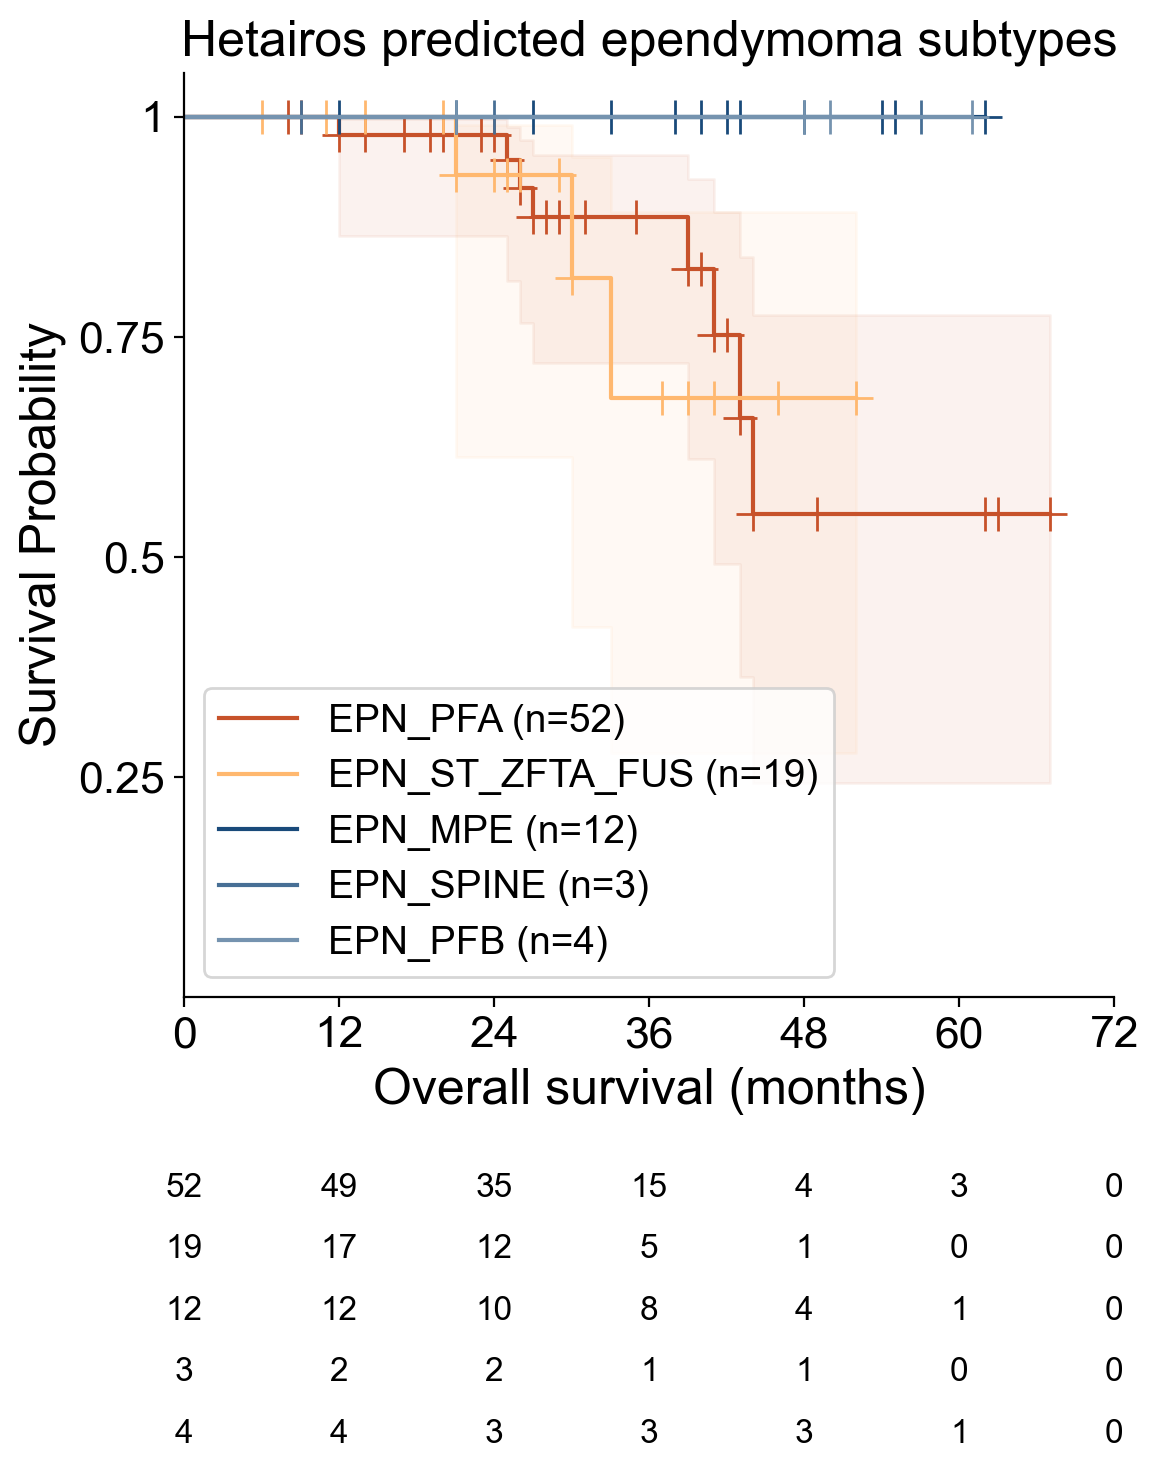

In [354]:
# survival analysis for the epndymoma group
epn_subset = preds_df[(preds_df['preds'].isin([1, 2, 13, 22, 37, 43])) & (~preds_df['os'].isna())]  # & (preds_df['who_type']=='ependymal tumor')
grp_epn_pfa = epn_subset[epn_subset['preds']==1]
grp_epn_zfta_fus = epn_subset[epn_subset['preds']==2]
grp_epn_mpe = epn_subset[epn_subset['preds']==13]
grp_epn_spine = epn_subset[epn_subset['preds']==22]
grp_epn_pfb = epn_subset[epn_subset['preds']==37]
# grp_epn_spine_se = epn_subset[epn_subset['preds']==43]
s_size = [len(grp_epn_pfa), len(grp_epn_zfta_fus), len(grp_epn_mpe), len(grp_epn_spine), len(grp_epn_pfb)]

from lifelines import KaplanMeierFitter
from matplotlib.ticker import FuncFormatter, MultipleLocator
%config InlineBackend.figure_format='retina'

colors = ['#c7522a', '#FFB86F', '#194a7a', '#476f95', '#7593af', '#a3b7ca']
kmf = KaplanMeierFitter()
lb = ['EPN_PFA', 'EPN_ST_ZFTA_FUS', 'EPN_MPE', 'EPN_SPINE', 'EPN_PFB'] # , 'EPN_SPINE_SE'
ax = plt.gca()
interval = 12
at_risk_data = []
for idx, grp in enumerate([grp_epn_pfa, grp_epn_zfta_fus, grp_epn_mpe, grp_epn_spine, grp_epn_pfb]): # , grp_epn_spine_se
    kmf.fit(grp['os'], event_observed=grp['event_code'], label=f"{lb[idx]} (n={s_size[idx]})")
    kmf.plot_survival_function(show_censors=True, figsize=(6, 6), color=colors[idx], ci_alpha=0.07)
    times = kmf.event_table.index
    at_risk = kmf.event_table['at_risk']
    selected_times = np.arange(0, 73, interval)
    selected_at_risk = [at_risk.iloc[times.searchsorted(t)] if t <= times.max() else 0 for t in selected_times]
    at_risk_data.append((lb[idx], selected_times, selected_at_risk))

for idx, (label, times, at_risk) in enumerate(at_risk_data):
    for t, n in zip(times, at_risk):
        ax.text(t, -0.2 - idx * 0.07, f"{int(n)}", 
                ha='center', va='top', fontsize=12, color='k')
    
ax = plt.gca()
plt.rcParams['font.family'] = 'Arial'
mpl.rcParams['pdf.fonttype'] = 42
plt.title('Hetairos predicted ependymoma subtypes', fontsize=18)
plt.xlabel('Overall survival (months)', fontsize=18)
plt.ylabel('Survival Probability', fontsize=18)
plt.legend(title='', loc='lower left', fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 1.05)
plt.xlim(0, 72)
ax.set_yticks([1, 0.75, 0.5, 0.25])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}' if y.is_integer() else f'{y}'))
ax.xaxis.set_major_locator(MultipleLocator(12)) 
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False) 
plt.show()

/var/folders/fj/2mkb2fwd27x3yb8l_fcvb6c80000gs/T/ipykernel_4489/1998869293.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epn_subset["labels"] = epn_subset["labels"].apply(
/var/folders/fj/2mkb2fwd27x3yb8l_fcvb6c80000gs/T/ipykernel_4489/1998869293.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  epn_subset["preds"] = epn_subset["preds"].apply(


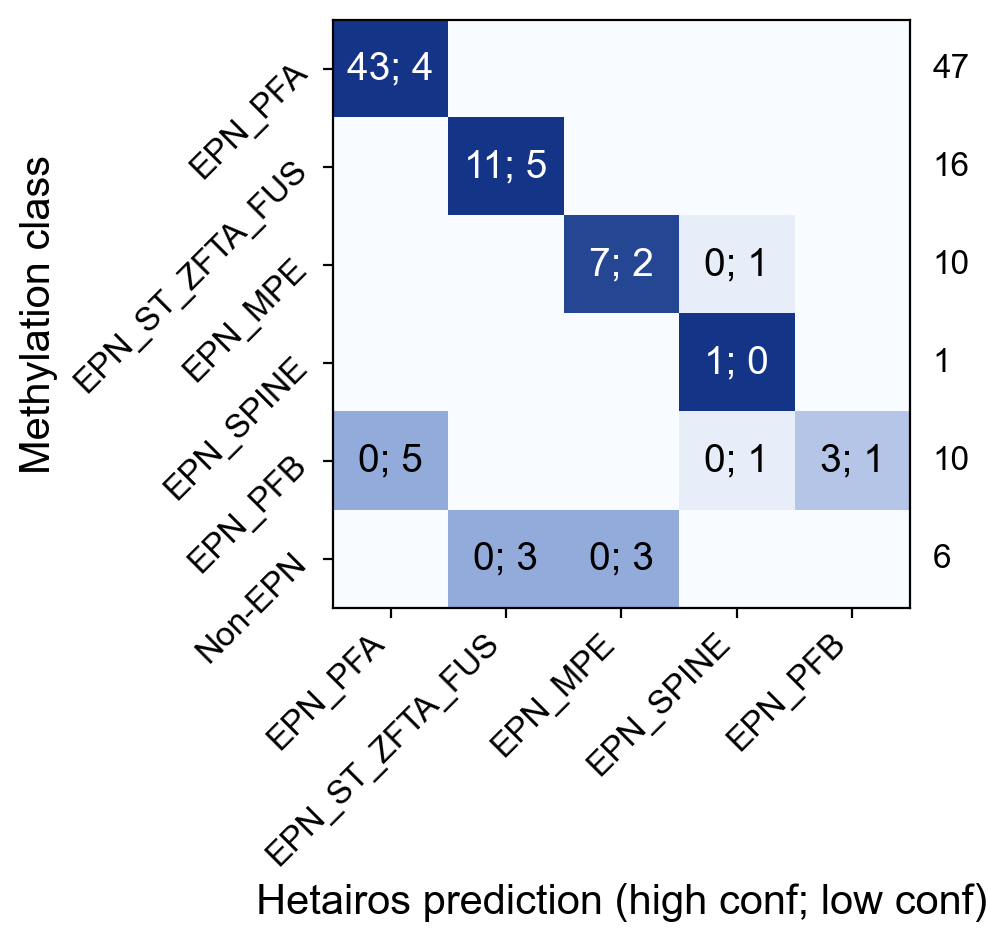

In [355]:
fig, ax = plt.subplots()
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
epn_subset["labels"] = epn_subset["labels"].apply(
    lambda x: x if x in [1, 2, 13, 22, 37, 43] else 108
)
epn_subset["preds"] = epn_subset["preds"].apply(
    lambda x: x if x in [1, 2, 13, 22, 37, 43] else 108
)

epn_subset_high_conf = epn_subset[epn_subset['top1_conf'] > 0.5]
epn_subset_low_conf = epn_subset[epn_subset['top1_conf'] <= 0.5]

cm = confusion_matrix(
    epn_subset["labels"].values,
    epn_subset["preds"].values,
    labels=[1, 2, 13, 22, 37] + [108],
)  # ,43
cm = cm[:, :5]

cm_high_conf = confusion_matrix(
    epn_subset_high_conf["labels"].values,
    epn_subset_high_conf["preds"].values,
    labels=[1, 2, 13, 22, 37] + [108],
)  # ,43
cm_high_conf = cm_high_conf[:, :5]

cm_low_conf = confusion_matrix(
    epn_subset_low_conf["labels"].values,
    epn_subset_low_conf["preds"].values,
    labels=[1, 2, 13, 22, 37] + [108],
)  # ,43
cm_low_conf = cm_low_conf[:, :5]

im = ax.imshow(
    cm / cm.sum(1, keepdims=True), interpolation="nearest", aspect=0.85, cmap=colormap
)  #
ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(6))
ax.set_xticklabels(
    ["EPN_PFA", "EPN_ST_ZFTA_FUS", "EPN_MPE", "EPN_SPINE", "EPN_PFB"],
    rotation=45,
    ha="right",
    fontsize=12,
)  # 'EPN_SPINE_SE'
ax.set_yticklabels(
    ["EPN_PFA", "EPN_ST_ZFTA_FUS", "EPN_MPE", "EPN_SPINE", "EPN_PFB", "Non-EPN"],
    fontsize=12,
    rotation=45,
)
ax.set_xlabel("Hetairos prediction (high conf; low conf)", fontsize=15)
ax.set_ylabel("Methylation class", fontsize=15)

for i in range(6):
    for j in range(5):
        np.set_printoptions(precision=2)
        values_ = cm[i, j] / cm.sum(1, keepdims=True)[i][0] * 100
        values = cm[i, j]
        if 50 < values_ <= 100:
            text = ax.text(
                j, i, "%.0f; %.0f" % (cm_high_conf[i, j], cm_low_conf[i, j]), ha="center", va="center", color="w", fontsize=14
            )
        elif 0 < values_ <= 50:
            text = ax.text(
                j,
                i,
                "%.0f; %.0f" % (cm_high_conf[i, j], cm_low_conf[i, j]),
                ha="center",
                va="center",
                color="black",
                fontsize=14,
            )
        else:
            pass

sample_counts_per_class = cm.sum(axis=1)
for i, count in enumerate(sample_counts_per_class):
    ax.text(
        cm.shape[1] - 0.3,
        i,
        str(count),
        va="center",
        fontsize=12,
        fontdict={"family": "Arial"},
    )

ax.tick_params(which="minor", bottom=False, left=False)
fig.tight_layout()
plt.show()

/var/folders/fj/2mkb2fwd27x3yb8l_fcvb6c80000gs/T/ipykernel_4489/3024767352.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hgg_subset['grp_pred'] = hgg_subset['preds'].map(assign_group)


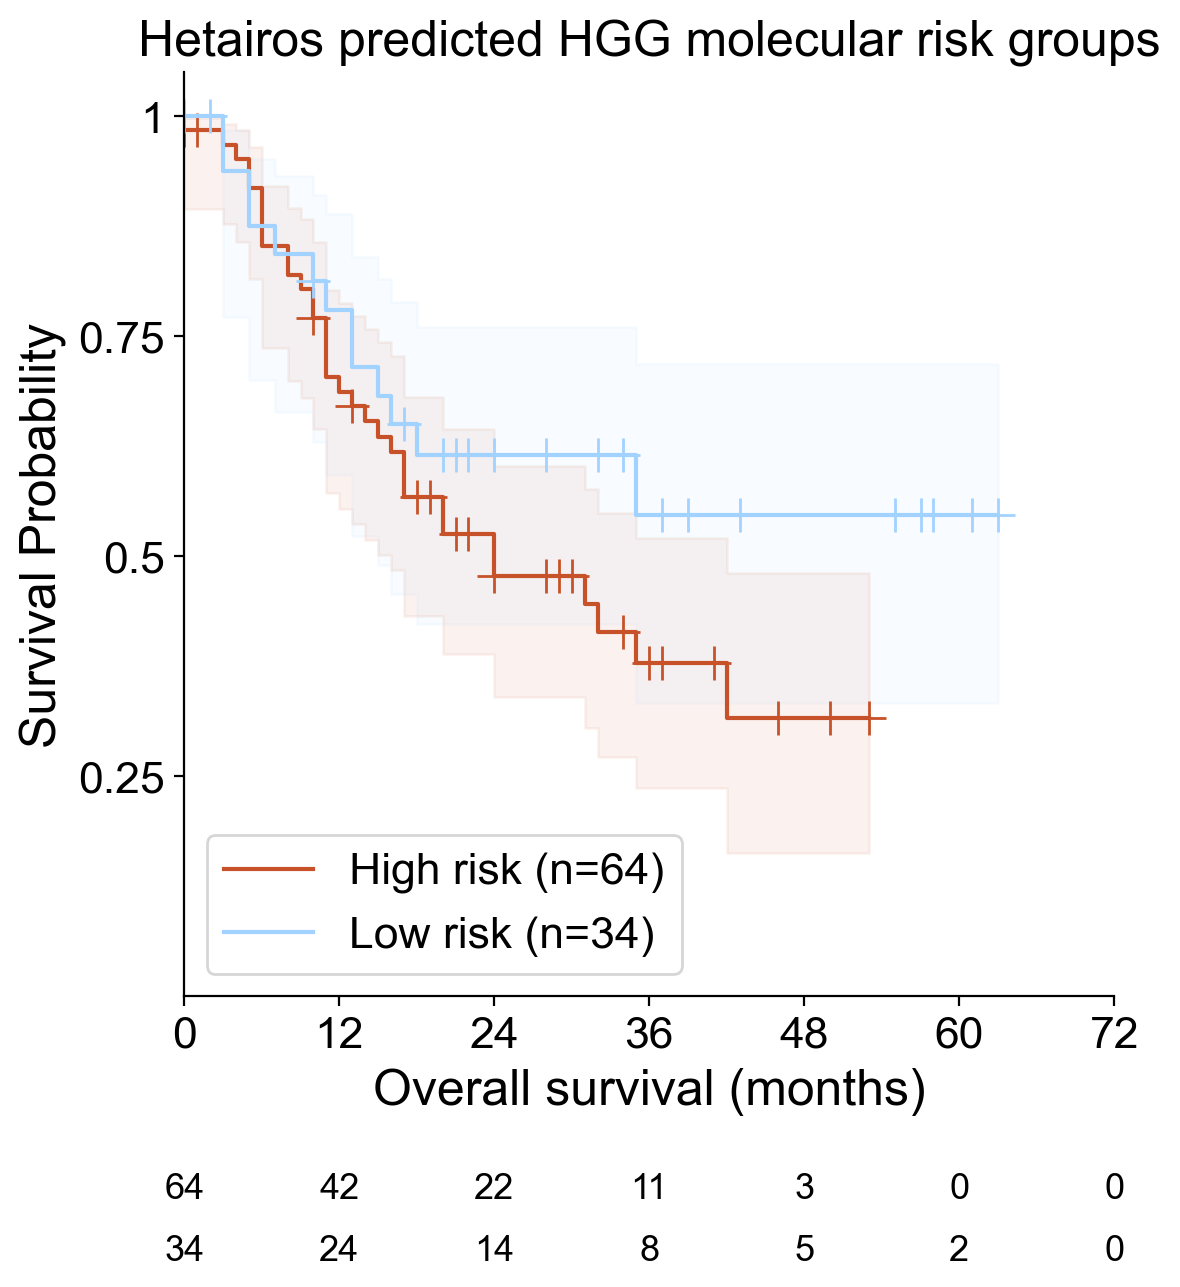

In [356]:
hgg_index = pd.read_csv('../backup/labels/MNP_HGG_HE_scanned_uuid.csv')
hgg_uuid = hgg_index['uuid'].to_list()

unknown_grp = pd.read_excel('../backup/labels/unknown_grp_mnp.xlsx')
unknown_grp.columns = unknown_grp.iloc[1]
unknown_grp = unknown_grp[2:]
unknown_grp['uuid'] = unknown_grp['patient ID'].map(ref_info_mnp.set_index('patient_ID')['uuid'].to_dict())
unknown_uuid = unknown_grp['uuid'].to_list()

hgg_subset = preds_df[(preds_df['uuid'].isin(hgg_uuid)) & (~preds_df['os'].isna())] #   & (~preds_df['uuid'].isin(unknown_uuid))

high_risk_grp = ['Diffuse midline glioma, H3 K27-altered', 'Diffuse hemispheric glioma, H3 G34-mutant', 'High-grade diffuse glioma of the midline/posterior fossa; H3/IDH-wildtype',
                'Diffuse paediatric-type high grade glioma', 'glioblastoma, IDH-wildtype'] 
low_risk_grp = ['Astrocytoma, IDH-mutant', 'Pleomorphic xanthoastrocytoma', 'Infant-type hemispheric glioma', 
                'CNS neuroblastoma, FOXR2-altered', 'High-grade astrocytoma with piloid features',
                'pilocytic astrocytoma', 'Ganglioglioma', 'diffuse glioma, MYB- or MYBL1-altered', 'Diffuse leptomeningeal glioneuronal tumour']
hgg_grp = high_risk_grp + low_risk_grp

high_risk_grp_ = [mapping[item] for item in high_risk_grp]
low_risk_grp_ = [mapping[item] for item in low_risk_grp]
hgg_grp_ = high_risk_grp_+low_risk_grp_

def assign_group(label):
    if label in high_risk_grp_:
        return 'h'  
    elif label in low_risk_grp_:
        return 'l'  
    else:
        return 'unknown' 
    
hgg_subset['grp_pred'] = hgg_subset['preds'].map(assign_group)
h_grp = hgg_subset[hgg_subset['preds'].isin(high_risk_grp_)]
l_grp = hgg_subset[hgg_subset['preds'].isin(low_risk_grp_)]
s_size = [len(h_grp), len(l_grp)]

from lifelines import KaplanMeierFitter
from matplotlib.ticker import FuncFormatter, MultipleLocator
%config InlineBackend.figure_format='retina'

colors = ['#c7522a', '#a2d2ff']
kmf = KaplanMeierFitter()
lb = ['High risk', 'Low risk']
ax = plt.gca()
interval = 12
at_risk_data = []
for idx, grp in enumerate([h_grp, l_grp]):
    kmf.fit(grp['os'], event_observed=grp['event_code'], label=f"{lb[idx]} (n={s_size[idx]})")
    kmf.plot_survival_function(show_censors=True, color=colors[idx], figsize=(6, 6), ci_alpha=0.07)
    times = kmf.event_table.index
    at_risk = kmf.event_table['at_risk']
    selected_times = np.arange(0, 73, interval)
    selected_at_risk = [at_risk.iloc[times.searchsorted(t)] if t <= times.max() else 0 for t in selected_times]
    at_risk_data.append((lb[idx], selected_times, selected_at_risk))

for idx, (label, times, at_risk) in enumerate(at_risk_data):
    for t, n in zip(times, at_risk):
        ax.text(t, -0.20 - idx * 0.07, f"{int(n)}", 
                ha='center', va='top', fontsize=13, color='k')

mpl.rcParams['pdf.fonttype'] = 42
plt.title('Hetairos predicted HGG molecular risk groups', fontsize=18)
plt.xlabel('Overall survival (months)', fontsize=18)
plt.ylabel('Survival Probability', fontsize=18)
plt.legend(title='', loc='lower left',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 1.05)
plt.xlim(0, 72)
ax.set_yticks([1, 0.75, 0.5, 0.25])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}' if y.is_integer() else f'{y}'))
ax.xaxis.set_major_locator(MultipleLocator(12))
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False) 
plt.show()

In [ ]:
paper_supplement = pd.read_excel(
    "./labels/41591_2023_2255_MOESM3_ESM.xlsx", skiprows=3
)
risk_group = paper_supplement[["patient ID", "RF-based HGG molecluar risk group"]]
risk_group = risk_group.dropna().reset_index(drop=True)
risk_group["uuid"] = risk_group["patient ID"].map(
    ref_info_mnp.set_index("patient_ID")["uuid"].to_dict()
)
hgg_subset["grp_label"] = hgg_subset["uuid"].map(
    risk_group.set_index("uuid")["RF-based HGG molecluar risk group"].to_dict()
)

In [ ]:
hgg_subset["grp_label"] = hgg_subset["grp_label"].apply(
    lambda x: "l" if x in ["intermediate", "low"] else x
)
hgg_subset["grp_label"] = hgg_subset["grp_label"].apply(
    lambda x: "unknown" if x in ["non-classifiable"] else x
)  # 'other/unknown',
hgg_subset["grp_label"] = hgg_subset["grp_label"].apply(
    lambda x: "h" if x == "high" else x
)

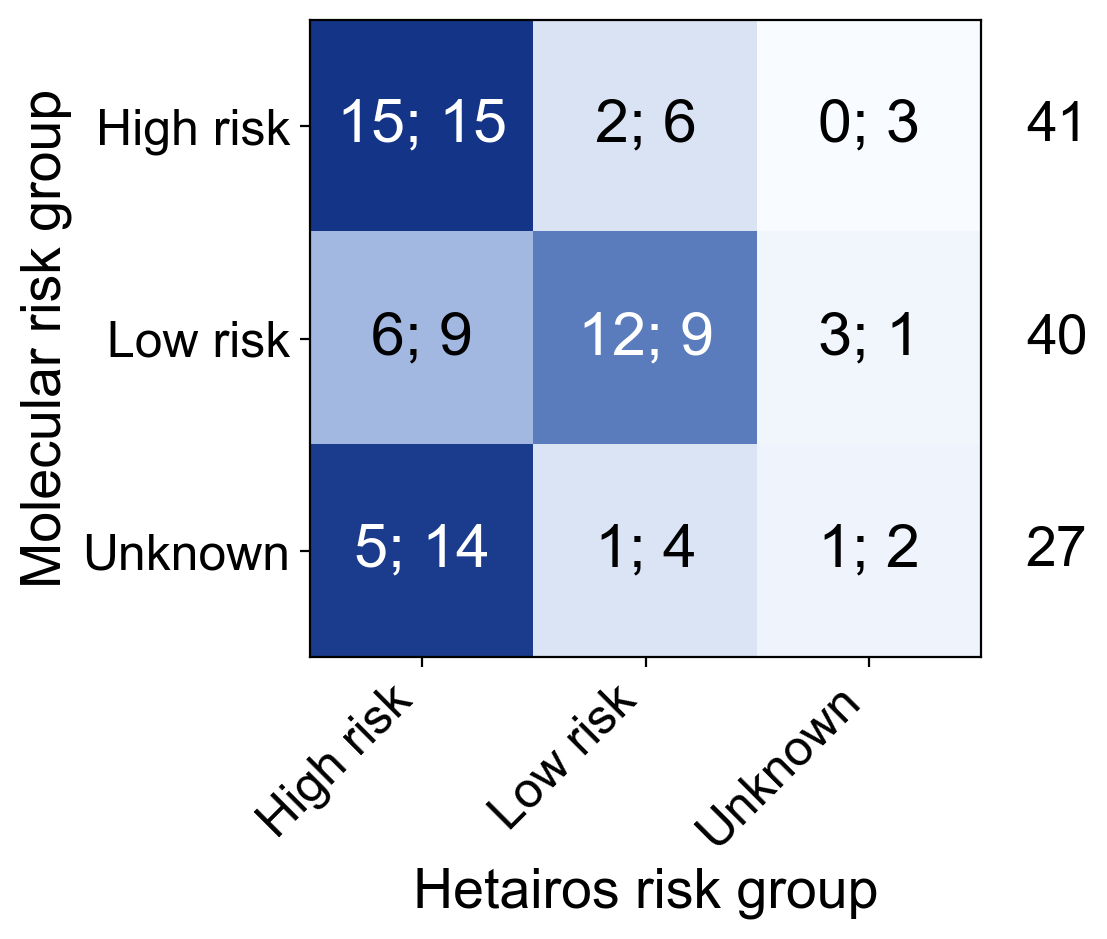

In [ ]:
fig, ax = plt.subplots()
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
cm = confusion_matrix(
    hgg_subset["grp_label"].values,
    hgg_subset["grp_pred"].values,
    labels=["h", "l", "unknown"],
)

hgg_high_conf = hgg_subset[hgg_subset['top1_conf'] > 0.5]
hgg_low_conf = hgg_subset[hgg_subset['top1_conf'] <= 0.5]

cm_high_conf = confusion_matrix(
    hgg_high_conf["grp_label"].values,
    hgg_high_conf["grp_pred"].values,
    labels=["h", "l", "unknown"],
)  # ,43
cm_high_conf = cm_high_conf[:, :5]

cm_low_conf = confusion_matrix(
    hgg_low_conf["grp_label"].values,
    hgg_low_conf["grp_pred"].values,
    labels=["h", "l", "unknown"],
)  # ,43
cm_low_conf = cm_low_conf[:, :5]

im = ax.imshow(
    cm / cm.sum(1, keepdims=True), interpolation="nearest", aspect=0.95, cmap=colormap
)  #
ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(
    ["High risk", "Low risk", "Unknown"], rotation=45, ha="right", fontsize=18
)
ax.set_yticklabels(["High risk", "Low risk", "Unknown"], fontsize=18)
ax.set_xlabel("Hetairos risk group", fontsize=20)
ax.set_ylabel("Molecular risk group", fontsize=20)

for i in range(3):
    for j in range(3):
        np.set_printoptions(precision=2)
        values_ = cm[i, j] / cm.sum(1, keepdims=True)[i][0] * 100
        values = cm[i, j]
        if 50 < values_ <= 100:
            text = ax.text(
                j, i, "%.0f; %.0f" % (cm_high_conf[i, j], cm_low_conf[i, j]), ha="center", va="center", color="w", fontsize=22
            )
        elif 0 < values_ <= 50:
            text = ax.text(
                j,
                i,
                "%.0f; %.0f" % (cm_high_conf[i, j], cm_low_conf[i, j]),
                ha="center",
                va="center",
                color="black",
                fontsize=22,
            )
        else:
            pass

sample_counts_per_class = cm.sum(axis=1)
for i, count in enumerate(sample_counts_per_class):
    ax.text(
        cm.shape[1] - 0.3,
        i,
        str(count),
        va="center",
        fontsize=20,
        fontdict={"family": "Arial"},
    )

ax.tick_params(which="minor", bottom=False, left=False)
fig.tight_layout()
plt.show()

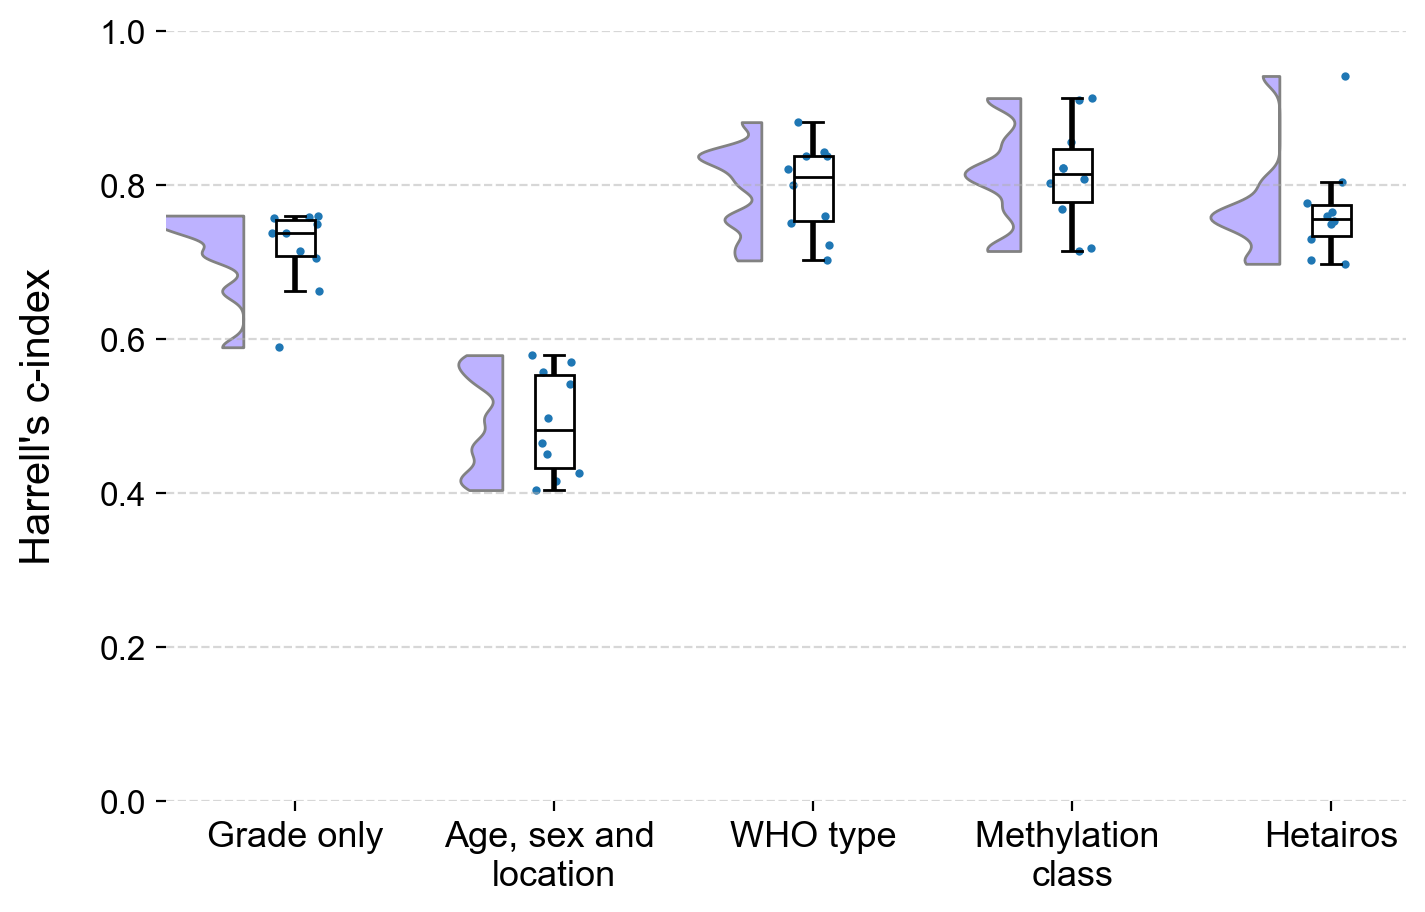

In [363]:
mnp_df = pd.read_csv(PREDICTIONS_DIR / 'survival_outer_cv_concordance.csv')
mnp_df.drop(columns=['Unnamed: 0', 'who_type_grade', 'heteiros_onehot', 'heteiros_age_sex_location', 'who_age_sex_location'], inplace=True)
import ptitprince as pt

fig, axes = plt.subplots(figsize=(8,5))
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.family': 'Arial'})
pt.RainCloud(data=mnp_df.melt(var_name='indicators', value_name='c_index'), x='indicators', y='c_index',
            order=['grade_only', 'age_sex_location', 'who_type', 'methylation_class', 'heteiros_preds'],
            box_showfliers=False, color='#bdb2ff')
plt.xticks([0,1,2,3,4], ['Grade only', 'Age, sex and \nlocation', 'WHO type', 'Methylation \nclass', 'Hetairos'], fontsize=13)
plt.ylabel("Harrell's c-index", fontsize=15, labelpad=15)
plt.yticks(fontsize=12)
plt.xlabel("")
plt.ylim(0., 1)
plt.box(False)
plt.grid(True, linestyle='--', axis='y', alpha=0.5)
plt.show()